# Avance 3: Modelo Baseline — Detección de Brotes de Sarampión
## Proyecto Integrador - Equipo 32

**Integrantes:**
- Luis Mauricio Castro Gutiérrez - A01795088
- Gerardo Miguel Pérez Solis - A01795599
- Amiel Joel Rosete Islas - A01748598

---

Este notebook consolida todos los modelos baseline para la detección de **brotes (picos anómalos)** de sarampión en México utilizando datos mensuales (2010–2023). Se implementan **siete enfoques** de detección de anomalías y se establecen métricas de referencia para evaluar modelos más avanzados en fases posteriores.

**Modelos implementados:**

| # | Método | Tipo | Idea Principal |
|---|--------|------|---------------|
| 1 | **Z-Score** | Estadístico | Un mes es anómalo si sus casos están a >N desviaciones estándar de la media histórica |
| 2 | **SARIMA / SARIMAX** | Series de Tiempo | Un mes es anómalo si su valor observado cae fuera del intervalo de predicción del modelo |
| 3 | **Holt-Winters** | Series de tiempo | Un mes es anómalo si el valor observado cae fuera del intervalo de predicción, incorpora nivel, tendencia y estacionalidad mediante suavizamiento exponencial. |
| 4 | **Prophet** | Series de Tiempo | Un valor observado fuera del intervalo de incertidumbre del modelo tendencia+estacionalidad es anómalo |
| 5 | **Bayesian Hierarchical** | Bayesiano conjugado | Detección vía p-values de la posterior predictiva Poisson-Gamma |
| 6 | **State Space (UCM)** | Series de Tiempo estructural | Detección vía intervalos de predicción del filtro de Kalman |
| 7 | **Poisson GLM** | Modelo de conteo | GLM con enlace log; predicción de conteos y detección por residuos |
| 8| **Negative Binomial GLM** | Modelo de conteo | GLM flexible para sobredispersión; detección por residuos |
| 9 | **Isolation Forest** | ML no supervisado | Los puntos anómalos se aíslan con menos particiones aleatorias en el espacio de features |


**Propósito del baseline:**
- Evaluar la **viabilidad del problema**: si el rendimiento es similar al azar, los datos podrían no contener suficiente información predictiva.
- Establecer una **solución mínima aceptable**: incluso un modelo simple puede aportar valor en vigilancia epidemiológica.
- Gestionar **expectativas** sobre lo que se puede lograr antes de invertir en enfoques más complejos.

## 1. Formulación del Problema como Detección de Anomalías

Los brotes de sarampión son eventos **raros y esporádicos**: solo ~10% de los meses en 2010–2023 registraron al menos un caso. Esta distribución extremadamente desbalanceada hace que el enfoque de **detección de anomalías** sea más apropiado que la regresión o clasificación convencional:

- **Normal** = mes sin casos de sarampión (≈90% de las observaciones).
- **Anomalía (brote)** = mes con ≥1 caso confirmado.

Los siete algoritmos de baseline se agrupan en cuatro familias:

| Familia | Métodos | Enfoque |
|---------|---------|---------|
| **Estadístico** | Z-Score (global + rolling) | Desviación respecto a media/σ histórica |
| **ML No Supervisado** | Isolation Forest | Aislamiento en espacio de features multivariado |
| **Series de Tiempo** | Prophet, State Space (UCM), SARIMA / SARIMAX  | Intervalos de predicción sobre tendencia + estacionalidad |
| **Bayesiano / Conteo** | Bayesian Hierarchical, Poisson GLM, Negative Binomial GLM | Distribuciones posteriores / residuos de modelos de conteo |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

from scipy.stats import nbinom as nbinom_dist

from sklearn.metrics import (
    confusion_matrix,
    f1_score, precision_score, recall_score,
    precision_recall_curve, auc, fbeta_score
)

from prophet import Prophet
from statsmodels.tsa.statespace.structural import UnobservedComponents
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import statsmodels.api as sm

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [2]:
# Montar Google Drive para acceder a datos (si se usa Colab)
#from google.colab import drive
#drive.mount('/content/drive')

In [3]:
# ---------- Carga de datos ----------
#descomentar la línea siguiente y ajustar el path si se usa Colab, o usar el path relativo para ejecutar localmente
#base_path = Path("/content/drive/MyDrive/Colab Notebooks/Proyecto integrador/Avance 3")
base_path = Path("..") / "data" / "processed"
# Dataset original (168 registros mensuales, 4 columnas base)
df_raw = pd.read_csv(base_path / "dataset_sarampion_vacunas_2010-2023.csv")

df_raw["fecha"] = pd.to_datetime(
    df_raw["anio"].astype(str) + "-" + df_raw["mes"].astype(str) + "-01"
)
df_raw = df_raw.sort_values("fecha").reset_index(drop=True)

# Dataset con ingeniería de características del Avance 2 (154 registros, 31 columnas)
df_fe = pd.read_csv(base_path / "dataset_sarampion_features_engineered.csv")
df_fe["fecha"] = pd.to_datetime(df_fe["fecha"])
df_fe = df_fe.sort_values("fecha").reset_index(drop=True)

# Variable objetivo binaria: brote = 1 si hay ≥1 caso
df_raw["brote"] = (df_raw["casos_sarampion"] > 0).astype(int)
df_fe["brote"]  = (df_fe["casos_sarampion"] > 0).astype(int)

print(f"Dataset original:    {df_raw.shape[0]} meses ({df_raw['fecha'].min().date()} → {df_raw['fecha'].max().date()})")
print(f"Dataset engineered:  {df_fe.shape[0]} meses ({df_fe['fecha'].min().date()} → {df_fe['fecha'].max().date()})")
print(f"\nMeses con brote (original):    {df_raw['brote'].sum()} / {len(df_raw)} ({df_raw['brote'].mean():.1%})")
print(f"Meses con brote (engineered):  {df_fe['brote'].sum()} / {len(df_fe)} ({df_fe['brote'].mean():.1%})")
print(f"\nAños con al menos un brote: {sorted(df_raw.loc[df_raw['brote']==1, 'anio'].unique())}")
display(df_raw.describe())

Dataset original:    168 meses (2010-01-01 → 2023-12-01)
Dataset engineered:  168 meses (2010-01-01 → 2023-12-01)

Meses con brote (original):    17 / 168 (10.1%)
Meses con brote (engineered):  17 / 168 (10.1%)

Años con al menos un brote: [2010, 2013, 2018, 2019, 2020]


,mes,anio,total_dosis,casos_sarampion,fecha,brote
count,168.000000,168.00000,1.680000e+02,168.000000,168,168.000000
mean,6.500000,2016.50000,3.153230e+05,2.261905,2016-12-15 16:17:08.571428608,0.101190
min,1.000000,2010.00000,1.115500e+04,0.000000,2010-01-01 00:00:00,0.000000
25%,3.750000,2013.00000,1.794778e+05,0.000000,2013-06-23 12:00:00,0.000000
50%,6.500000,2016.50000,2.292330e+05,0.000000,2016-12-16 12:00:00,0.000000
75%,9.250000,2020.00000,3.167408e+05,0.000000,2020-06-08 12:00:00,0.000000
max,12.000000,2023.00000,3.130610e+06,81.000000,2023-12-01 00:00:00,1.000000
std,3.462373,4.04318,3.567464e+05,11.132968,NaN,0.302482


## 2. Definición de Métricas

En vigilancia epidemiológica, **no detectar un brote** (falso negativo) tiene consecuencias mucho más graves que una **falsa alarma** (falso positivo):

| Tipo de Error | Consecuencia | Gravedad |
|---------------|-------------|----------|
| **Falso Negativo** (brote no detectado) | Propagación comunitaria sin intervención oportuna; riesgo de epidemia | 🔴 Crítica |
| **Falso Positivo** (falsa alarma) | Investigación epidemiológica innecesaria; costo operativo menor | 🟡 Moderada |

Por tanto, la jerarquía de métricas es:

| Métrica | Prioridad | Justificación |
|---------|-----------|---------------|
| **Recall** | 🔴 Alta | Proporción de brotes reales detectados |
| **F2-Score** | 🔴 Alta | Pondera Recall 2× más que Precision |
| **Precision** | 🟡 Media | Proporción de alertas que son brotes reales |
| **F1-Score** | 🟡 Media | Balance armónico entre Precision y Recall |
| **AUC-PR** | 🟡 Media | Robusta ante desbalance extremo de clases |

> **Métrica principal:** F2-Score (pondera Recall sobre Precision).
> **Métrica secundaria:** Recall — debe ser > 0 para que el modelo tenga utilidad.

In [4]:
def evaluar_detector(y_true, y_pred, nombre, y_score=None):
    """Evalúa un detector de anomalías con métricas epidemiológicas."""
    p  = precision_score(y_true, y_pred, zero_division=0)
    r  = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    f2 = fbeta_score(y_true, y_pred, beta=2, zero_division=0)

    auc_pr = np.nan
    if y_score is not None and y_true.sum() > 0:
        prec_c, rec_c, _ = precision_recall_curve(y_true, y_score)
        auc_pr = auc(rec_c, prec_c)

    result = {
        "Modelo": nombre,
        "Precision": round(p, 3),
        "Recall": round(r, 3),
        "F1": round(f1, 3),
        "F2": round(f2, 3),
        "AUC-PR": round(auc_pr, 3) if not np.isnan(auc_pr) else np.nan,
        "Brotes_detectados": int(y_pred[y_true == 1].sum()),
        "Brotes_reales": int(y_true.sum()),
        "Falsas_alarmas": int(y_pred[y_true == 0].sum()),
    }

    print(f"\n{'=' * 55}")
    print(f"  {nombre}")
    print(f"{'=' * 55}")
    print(f"  Precision:         {p:.3f}")
    print(f"  Recall:            {r:.3f}")
    print(f"  F1-Score:          {f1:.3f}")
    print(f"  F2-Score:          {f2:.3f}")
    if not np.isnan(auc_pr):
        print(f"  AUC-PR:            {auc_pr:.3f}")
    print(f"  Brotes detectados: {int(y_pred[y_true == 1].sum())} / {int(y_true.sum())}")
    print(f"  Falsas alarmas:    {int(y_pred[y_true == 0].sum())}")

    return result

#### **Visualización de serie temporal con brotes**

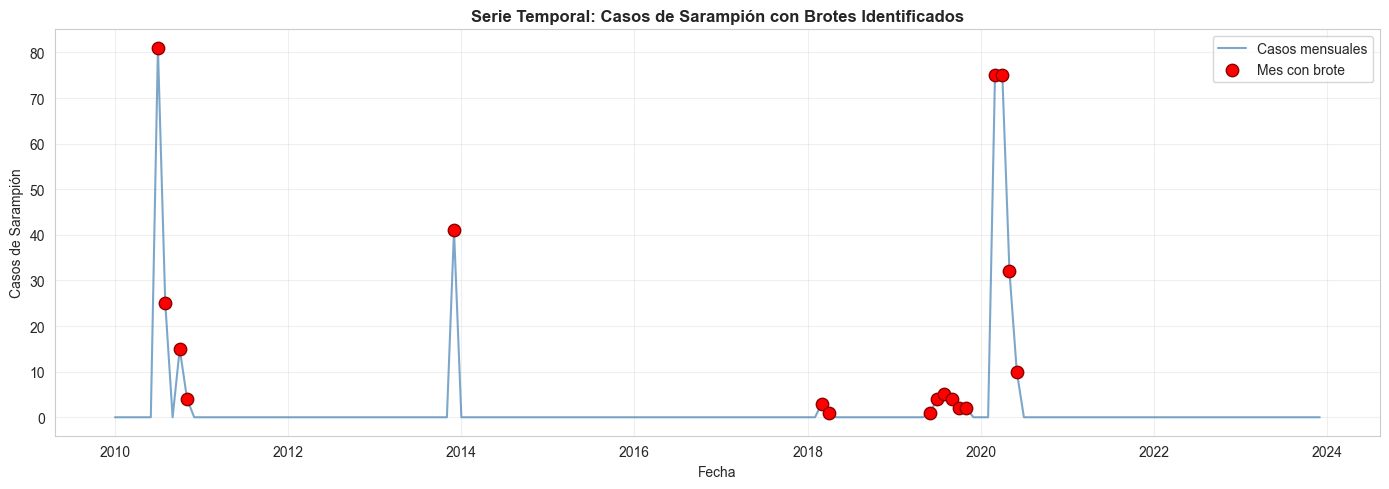


Clase 0 (sin brote): 151 meses
Clase 1 (brote):     17 meses
Ratio de desbalance: 8:1


In [5]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_raw["fecha"], df_raw["casos_sarampion"],
        color="steelblue", alpha=0.7, label="Casos mensuales")

brotes_mask = df_raw["brote"] == 1
ax.scatter(df_raw.loc[brotes_mask, "fecha"],
           df_raw.loc[brotes_mask, "casos_sarampion"],
           color="red", s=80, zorder=5, label="Mes con brote", edgecolors="darkred")

ax.set_xlabel("Fecha")
ax.set_ylabel("Casos de Sarampión")
ax.set_title("Serie Temporal: Casos de Sarampión con Brotes Identificados", fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

n0 = (df_raw["brote"] == 0).sum()
n1 = (df_raw["brote"] == 1).sum()
print(f"\nClase 0 (sin brote): {n0} meses")
print(f"Clase 1 (brote):     {n1} meses")
print(f"Ratio de desbalance: {n0 // max(n1, 1)}:1")

## 3. Partición Temporal

Se realiza un split cronológico estricto para respetar la naturaleza temporal de los datos:

- **Entrenamiento (fit):** 2010–2018 — historia previa a los brotes principales.
- **Prueba (score):** 2019–2023 — incluye los brotes significativos de 2019–2020 y el período post-brote, permitiendo evaluar tanto la detección de anomalías reales como la tasa de falsas alarmas.

**Justificación del corte en 2019:**
Los principales brotes de sarampión en México ocurrieron en 2019–2020. Incluirlos en el set de prueba permite evaluar Recall y F2-Score de forma significativa. Un corte posterior (e.g., 2021) dejaría el test sin brotes reales, haciendo imposible medir la sensibilidad del detector.

In [6]:
SPLIT_YEAR = 2019

train_raw = df_raw[df_raw["anio"] < SPLIT_YEAR].copy()
test_raw  = df_raw[df_raw["anio"] >= SPLIT_YEAR].copy()

#Para Isolation Forest, Poisson GLM, NB GLM) ---
train_fe = df_fe[df_fe["anio"] < SPLIT_YEAR].copy()
test_fe  = df_fe[df_fe["anio"] >= SPLIT_YEAR].copy()

y_true_full = df_raw["brote"].values

print("Partición temporal")
print(f"{'─' * 60}")
print(f"  Train (original):    {len(train_raw):>4} meses | Brotes: {train_raw['brote'].sum()}")
print(f"  Test  (original):    {len(test_raw):>4} meses | Brotes: {test_raw['brote'].sum()}")
print(f"  Train (engineered):  {len(train_fe):>4} meses | Brotes: {train_fe['brote'].sum()}")
print(f"  Test  (engineered):  {len(test_fe):>4} meses | Brotes: {test_fe['brote'].sum()}")
if test_raw["brote"].sum() == 0:
    print("\nEl set de prueba NO contiene brotes.")
    print("La evaluación en test medirá principalmente falsas alarmas.")
else:
    print(f"\nEl set de prueba contiene {test_raw['brote'].sum()} meses con brote.")

Partición temporal
────────────────────────────────────────────────────────────
  Train (original):     108 meses | Brotes: 7
  Test  (original):      60 meses | Brotes: 10
  Train (engineered):   108 meses | Brotes: 7
  Test  (engineered):    60 meses | Brotes: 10

El set de prueba contiene 10 meses con brote.


**Se crea una lista para cumular los resultados de los modelos**

In [7]:
all_results = []

## 4. Baseline 1: Detección por Z-Score

### Fundamento

El Z-Score mide cuántas desviaciones estándar se aleja una observación de la media

**Variantes implementadas:**
1. **Z-Score global:** usa $\mu$ y $\sigma$ de toda la serie de entrenamiento.
2. **Z-Score rolling:** usa una ventana móvil de 12 meses previos, capturando cambios en la dinámica local.

In [8]:
mu_train    = train_raw["casos_sarampion"].mean()
sigma_train = train_raw["casos_sarampion"].std()

df_raw["zscore_global"] = (df_raw["casos_sarampion"] - mu_train) / sigma_train

ROLLING_WINDOW = 12
r_mean = df_raw["casos_sarampion"].shift(1).rolling(ROLLING_WINDOW, min_periods=3).mean()
r_std  = df_raw["casos_sarampion"].shift(1).rolling(ROLLING_WINDOW, min_periods=3).std()
r_std  = r_std.replace(0, np.nan)  # evitar div/0

df_raw["zscore_rolling"] = (df_raw["casos_sarampion"] - r_mean) / r_std

print("Estadísticos de entrenamiento (Z-Score Global):")
print(f"  μ = {mu_train:.3f} casos/mes")
print(f"  σ = {sigma_train:.3f}")
print(f"  Umbral z>1 ≈ {mu_train + 1*sigma_train:.1f} casos")
print(f"  Umbral z>2 ≈ {mu_train + 2*sigma_train:.1f} casos")
print(f"  Umbral z>3 ≈ {mu_train + 3*sigma_train:.1f} casos")

Estadísticos de entrenamiento (Z-Score Global):
  μ = 1.574 casos/mes
  σ = 9.095
  Umbral z>1 ≈ 10.7 casos
  Umbral z>2 ≈ 19.8 casos
  Umbral z>3 ≈ 28.9 casos


**Barrido de umbrales**

In [9]:
thresholds_z = [0.0, 0.25, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
rows_z = []
for t in thresholds_z:
    yp = (df_raw["zscore_global"] > t).astype(int).values
    rows_z.append({
        "Umbral z": t,
        "Precision": round(precision_score(y_true_full, yp, zero_division=0), 3),
        "Recall":    round(recall_score(y_true_full, yp, zero_division=0), 3),
        "F1":        round(f1_score(y_true_full, yp, zero_division=0), 3),
        "F2":        round(fbeta_score(y_true_full, yp, beta=2, zero_division=0), 3),
        "Detectados": int(yp[y_true_full == 1].sum()),
        "Falsas_alarmas": int(yp[y_true_full == 0].sum()),
    })

df_thresh_z = pd.DataFrame(rows_z)
print("\nBarrido de umbrales — Z-Score Global:")
display(df_thresh_z)


Barrido de umbrales — Z-Score Global:


,Umbral z,Precision,Recall,F1,F2,Detectados,Falsas_alarmas
0,0.00,1.0,0.882,0.938,0.904,15,0
1,0.25,1.0,0.706,0.828,0.750,12,0
2,0.50,1.0,0.471,0.640,0.526,8,0
3,1.00,1.0,0.412,0.583,0.467,7,0
4,1.50,1.0,0.353,0.522,0.405,6,0
5,2.00,1.0,0.353,0.522,0.405,6,0
6,2.50,1.0,0.353,0.522,0.405,6,0
7,3.00,1.0,0.294,0.455,0.342,5,0


In [10]:
best_idx = df_thresh_z["F2"].idxmax()
BEST_Z   = df_thresh_z.loc[best_idx, "Umbral z"]
print(f"Mejor umbral por F2: z > {BEST_Z}")

Mejor umbral por F2: z > 0.0


**Evaluación de mejor umbral zscore**


  Z-Score Global (z > 0.0)
  Precision:         1.000
  Recall:            0.882
  F1-Score:          0.938
  F2-Score:          0.904
  AUC-PR:            1.000
  Brotes detectados: 15 / 17
  Falsas alarmas:    0


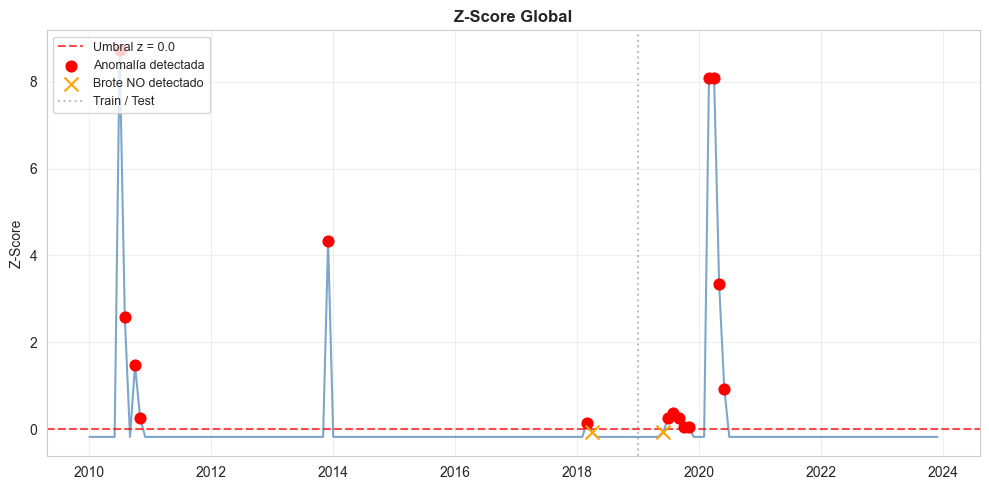

In [11]:
y_pred_zg  = (df_raw["zscore_global"] > BEST_Z).astype(int).values
score_zg   = df_raw["zscore_global"].values
res_zg     = evaluar_detector(y_true_full, y_pred_zg,
                              f"Z-Score Global (z > {BEST_Z})",
                              y_score=score_zg)
all_results.append(res_zg)

# ---- Visualización ----
fig, axes = plt.subplots(1, 1, figsize=(10, 5), sharex=True)

# Panel 1: Z-Score Global
axes.plot(df_raw["fecha"], df_raw["zscore_global"], color="steelblue", alpha=0.7)
axes.axhline(BEST_Z, color="red", ls="--", alpha=0.7, label=f"Umbral z = {BEST_Z}")
det_g = df_raw.index[y_pred_zg == 1]
axes.scatter(df_raw.loc[det_g, "fecha"], df_raw.loc[det_g, "zscore_global"],
                color="red", s=60, zorder=5, label="Anomalía detectada")
missed_g = df_raw.index[(df_raw["brote"] == 1) & (y_pred_zg == 0)]
if len(missed_g):
    axes.scatter(df_raw.loc[missed_g, "fecha"], df_raw.loc[missed_g, "zscore_global"],
                    color="orange", marker="x", s=100, zorder=5, label="Brote NO detectado")
axes.axvline(pd.Timestamp(f"{SPLIT_YEAR}-01-01"), color="gray", ls=":", alpha=0.5, label="Train / Test")
axes.set_ylabel("Z-Score")
axes.set_title("Z-Score Global", fontweight="bold")
axes.legend(fontsize=9, loc="upper left")
axes.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Evaluación Z-Score Rolling**


  Z-Score Rolling 12m (z > 0.0)
  Precision:         1.000
  Recall:            0.846
  F1-Score:          0.917
  F2-Score:          0.873
  AUC-PR:            0.958
  Brotes detectados: 11 / 13
  Falsas alarmas:    0


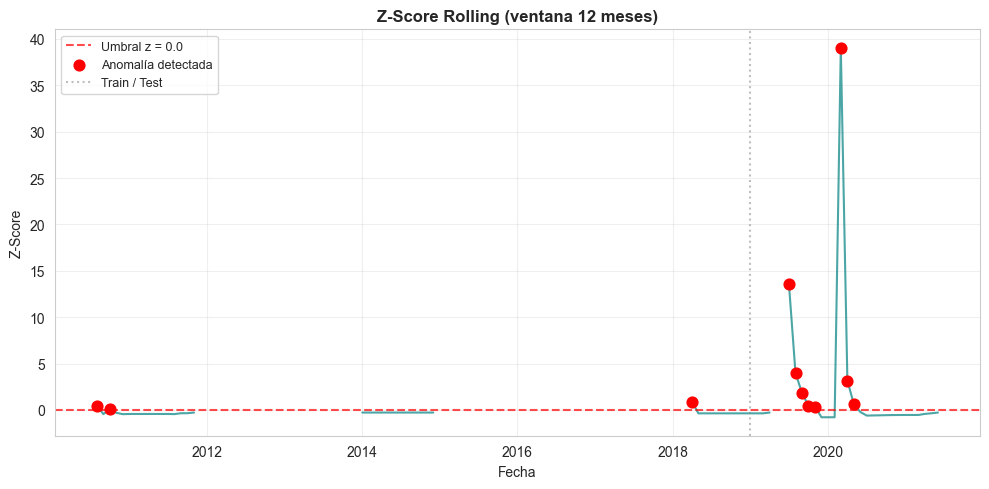

In [12]:
valid_mask  = ~df_raw["zscore_rolling"].isna()
y_true_v    = df_raw.loc[valid_mask, "brote"].values
y_pred_zr   = (df_raw.loc[valid_mask, "zscore_rolling"] > BEST_Z).astype(int).values
score_zr    = df_raw.loc[valid_mask, "zscore_rolling"].values
res_zr      = evaluar_detector(y_true_v, y_pred_zr,
                               f"Z-Score Rolling 12m (z > {BEST_Z})",
                               y_score=score_zr)
all_results.append(res_zr)

fig, axes = plt.subplots(1, 1, figsize=(10, 5), sharex=True)
axes.plot(df_raw["fecha"], df_raw["zscore_rolling"], color="teal", alpha=0.7)
axes.axhline(BEST_Z, color="red", ls="--", alpha=0.7, label=f"Umbral z = {BEST_Z}")
det_r = df_raw.index[(df_raw["zscore_rolling"] > BEST_Z).fillna(False)]
if len(det_r):
    axes.scatter(df_raw.loc[det_r, "fecha"], df_raw.loc[det_r, "zscore_rolling"],
                    color="red", s=60, zorder=5, label="Anomalía detectada")
axes.axvline(pd.Timestamp(f"{SPLIT_YEAR}-01-01"), color="gray", ls=":", alpha=0.5, label="Train / Test")
axes.set_ylabel("Z-Score")
axes.set_xlabel("Fecha")
axes.set_title("Z-Score Rolling (ventana 12 meses)", fontweight="bold")
axes.legend(fontsize=9, loc="upper left")
axes.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Matrices de confusión Z-Score Global y Z-Score Rolling**

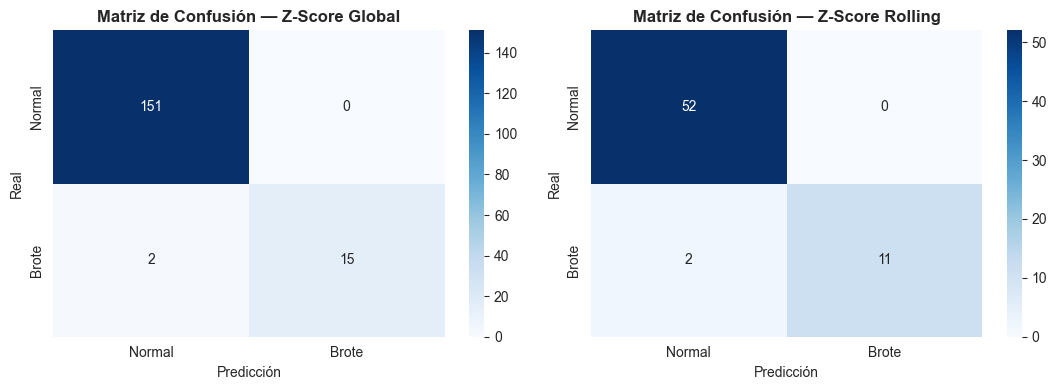

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, yp, yt, title in [
    (axes[0], y_pred_zg, y_true_full, "Z-Score Global"),
    (axes[1], y_pred_zr, y_true_v,    "Z-Score Rolling"),
]:
    cm = confusion_matrix(yt, yp)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Normal", "Brote"], yticklabels=["Normal", "Brote"])
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")
    ax.set_title(f"Matriz de Confusión — {title}", fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Baseline 2: SARIMA / SARIMAX

###Fundamento

SARIMA modela explícitamente:
- dependencia temporal (AR/MA),
- tendencia/diferenciación,
- estacionalidad (mensual, período 12 meses).




In [14]:
y_train_counts = train_raw["casos_sarampion"].values
y_full_counts  = df_raw["casos_sarampion"].values

order = (1, 0, 1)
seasonal_order = (1, 0, 1, 12)

sarima = SARIMAX(
    train_raw["casos_sarampion"],
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

pred_full = sarima.get_prediction(
    start=df_raw.index.min(),
    end=df_raw.index.max()
).predicted_mean.values

resid_full = y_full_counts - pred_full
resid_train = resid_full[df_raw["anio"] < SPLIT_YEAR]
sd_resid = resid_train.std(ddof=0) + 1e-9

k_candidates = np.linspace(0.5, 4.0, 15)
best_k = None
best_f2 = -1

y_train_brote = train_raw["brote"].values
resid_train_std = resid_train / sd_resid

for k in k_candidates:
    yp_train = (resid_train_std > k).astype(int)
    f2 = fbeta_score(y_train_brote, yp_train, beta=2, zero_division=0)
    if f2 > best_f2:
        best_f2 = f2
        best_k = float(k)

print(f"SARIMA mejor k (train): {best_k:.2f} | F2(train): {best_f2:.3f}")

resid_full_std = resid_full / sd_resid
y_pred_sarima_full = (resid_full_std > best_k).astype(int)

res_sarima = evaluar_detector(
    y_true_full, y_pred_sarima_full,
    f"SARIMA resid > {best_k:.2f}σ",
    y_score=resid_full_std
)
all_results.append(res_sarima)

SARIMA mejor k (train): 0.50 | F2(train): 0.625

  SARIMA resid > 0.50σ
  Precision:         1.000
  Recall:            0.529
  F1-Score:          0.692
  F2-Score:          0.584
  AUC-PR:            1.000
  Brotes detectados: 9 / 17
  Falsas alarmas:    0


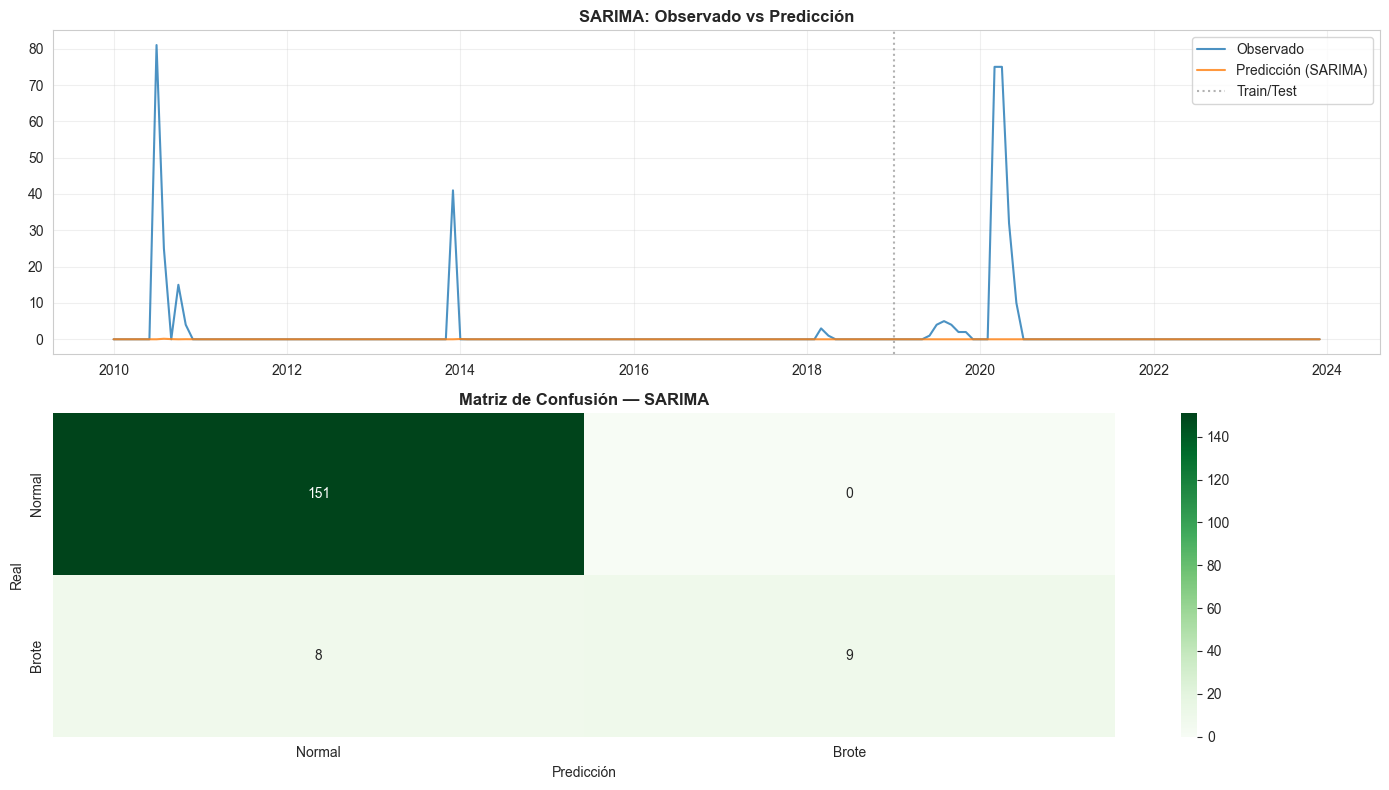

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(df_raw["fecha"], df_raw["casos_sarampion"], label="Observado", alpha=0.8)
axes[0].plot(df_raw["fecha"], pred_full, label="Predicción (SARIMA)", alpha=0.8)
axes[0].axvline(pd.Timestamp(f"{SPLIT_YEAR}-01-01"), color="gray", ls=":", alpha=0.6, label="Train/Test")
axes[0].set_title("SARIMA: Observado vs Predicción", fontweight="bold")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

cm = confusion_matrix(y_true_full, y_pred_sarima_full)
sns.heatmap(cm, annot=True, fmt="d", ax=axes[1], cmap="Greens",
            xticklabels=["Normal", "Brote"], yticklabels=["Normal", "Brote"])
axes[1].set_title("Matriz de Confusión — SARIMA", fontweight="bold")
axes[1].set_xlabel("Predicción")
axes[1].set_ylabel("Real")

plt.tight_layout()
plt.show()

## 6. Baseline 3: Holt-Winters
###Fundamento
Holt-Winters (Exponential Smoothing) es un baseline temporal clásico que modela:
- nivel
- tendencia
- estacionalidad

In [16]:
ets = ExponentialSmoothing(
    train_raw["casos_sarampion"],
    trend="add",
    seasonal="add",
    seasonal_periods=12
).fit(optimized=True)

# Predicción (train + test)
pred_ets_full = ets.predict(start=df_raw.index.min(), end=df_raw.index.max()).values

resid_ets_full = y_full_counts - pred_ets_full
resid_ets_train = resid_ets_full[df_raw["anio"] < SPLIT_YEAR]
sd_ets = resid_ets_train.std(ddof=0) + 1e-9

k_candidates = np.linspace(0.5, 4.0, 15)
best_k_ets = None
best_f2_ets = -1

resid_train_std = resid_ets_train / sd_ets

for k in k_candidates:
    yp_train = (resid_train_std > k).astype(int)
    f2 = fbeta_score(y_train_brote, yp_train, beta=2, zero_division=0)
    if f2 > best_f2_ets:
        best_f2_ets = f2
        best_k_ets = float(k)

print(f"ETS mejor k (train): {best_k_ets:.2f} | F2(train): {best_f2_ets:.3f}")

resid_ets_full_std = resid_ets_full / sd_ets
y_pred_ets_full = (resid_ets_full_std > best_k_ets).astype(int)

res_ets = evaluar_detector(
    y_true_full, y_pred_ets_full,
    f"Holt-Winters resid > {best_k_ets:.2f}σ",
    y_score=resid_ets_full_std
)
all_results.append(res_ets)

ETS mejor k (train): 0.50 | F2(train): 0.758

  Holt-Winters resid > 0.50σ
  Precision:         0.317
  Recall:            0.765
  F1-Score:          0.448
  F2-Score:          0.596
  AUC-PR:            0.687
  Brotes detectados: 13 / 17
  Falsas alarmas:    28


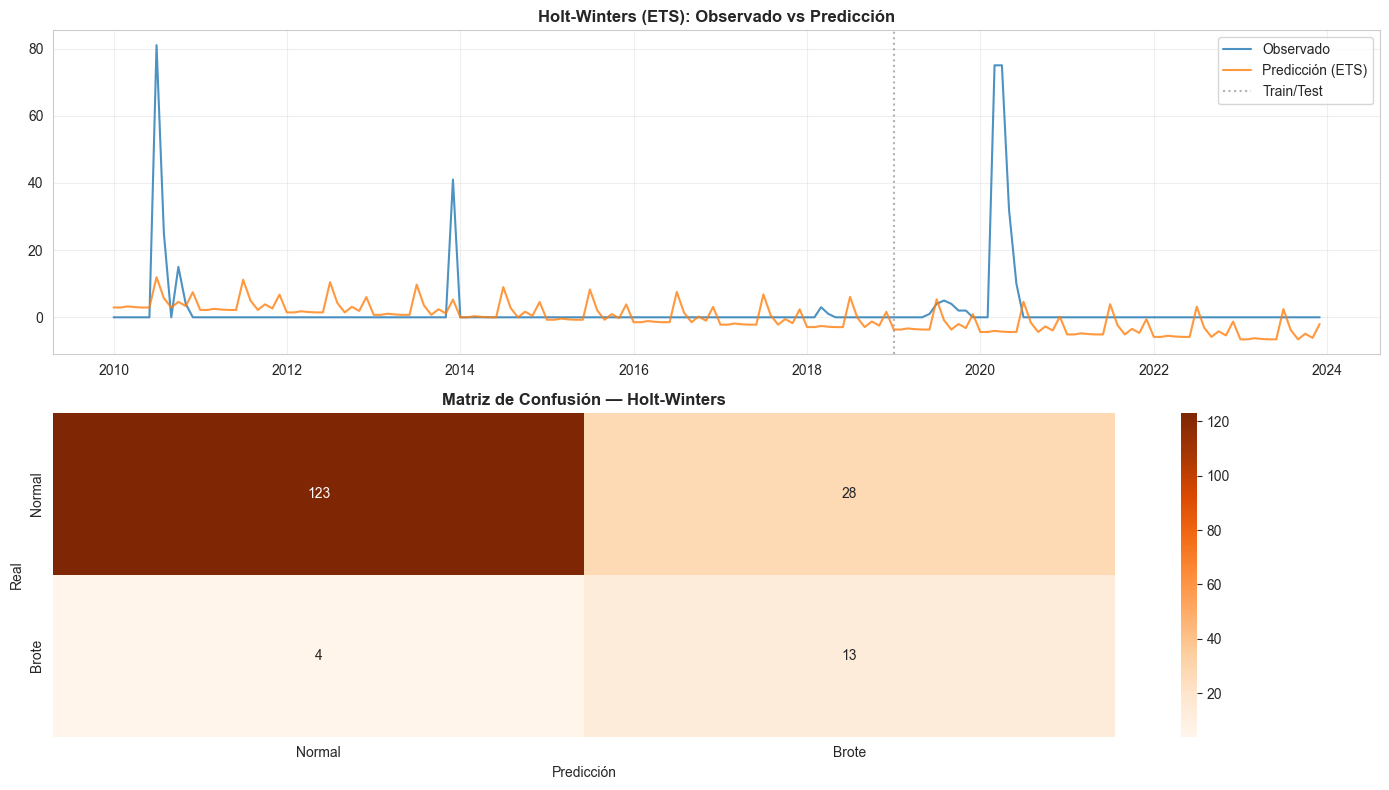

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(df_raw["fecha"], df_raw["casos_sarampion"], label="Observado", alpha=0.8)
axes[0].plot(df_raw["fecha"], pred_ets_full, label="Predicción (ETS)", alpha=0.8)
axes[0].axvline(pd.Timestamp(f"{SPLIT_YEAR}-01-01"), color="gray", ls=":", alpha=0.6, label="Train/Test")
axes[0].set_title("Holt-Winters (ETS): Observado vs Predicción", fontweight="bold")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

cm = confusion_matrix(y_true_full, y_pred_ets_full)
sns.heatmap(cm, annot=True, fmt="d", ax=axes[1], cmap="Oranges",
            xticklabels=["Normal", "Brote"], yticklabels=["Normal", "Brote"])
axes[1].set_title("Matriz de Confusión — Holt-Winters", fontweight="bold")
axes[1].set_xlabel("Predicción")
axes[1].set_ylabel("Real")

plt.tight_layout()
plt.show()

## 7. Baseline 4: Prophet
### Fundamento

Prophet es un modelo de series de tiempo desarrollado por Meta.

El uso de Prophet es ideal para este problema porque está diseñado específicamente para superar los retos de los datos epidemiológicos del mundo real. A diferencia de modelos tradicionales, Prophet es muy robusto ante datos faltantes o valores atípicos (como retrasos o errores en los reportes de salud) y modela con gran precisión múltiples estacionalidades, lo cual es perfecto para capturar los ciclos naturales del sarampión. Además, detecta automáticamente cambios drásticos en la tendencia, permitiendo evaluar exactamente cómo las caídas o aumentos en las tasas de vacunación alteran la curva de contagios.

**Configuración:**
- Se ajusta sobre datos de entrenamiento (2010–2018) y se pronostica todo el período.
- `interval_width=0.95` (intervalo de confianza al 95%).
- `changepoint_prior_scale=0.05` (conservador, evita sobreajuste a fluctuaciones locales).

In [18]:
df_prophet_train = pd.DataFrame({
    "ds": train_raw["fecha"],
    "y":  train_raw["casos_sarampion"],
})

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    interval_width=0.95,
    changepoint_prior_scale=0.05,
    seasonality_mode="additive",
)
prophet_model.fit(df_prophet_train)

future = pd.DataFrame({"ds": df_raw["fecha"]})
forecast = prophet_model.predict(future)

# Detectar anomalías: observado > yhat_upper
df_raw["prophet_yhat"]    = forecast["yhat"].values
df_raw["prophet_upper"]   = forecast["yhat_upper"].values
df_raw["prophet_lower"]   = forecast["yhat_lower"].values
df_raw["prophet_anomaly"] = (df_raw["casos_sarampion"] > forecast["yhat_upper"].values).astype(int)

#Evaluación
y_pred_prophet = df_raw["prophet_anomaly"].values
prophet_score = df_raw["casos_sarampion"].values - df_raw["prophet_upper"].values

res_prophet = evaluar_detector(y_true_full, y_pred_prophet,
                               "Prophet",
                               y_score=prophet_score)
all_results.append(res_prophet)

#Evaluación temporal
y_test_prophet = test_raw["brote"].values
y_pred_prophet_test = df_raw.loc[df_raw["anio"] >= SPLIT_YEAR, "prophet_anomaly"].values
if y_test_prophet.sum() > 0:
    evaluar_detector(y_test_prophet, y_pred_prophet_test, "Prophet (test)")
else:
    fa_prophet_test = int(y_pred_prophet_test.sum())
    print(f"\n  Prophet (test {SPLIT_YEAR}–2023): Sin brotes reales en test.")
    print(f"  Falsas alarmas en test: {fa_prophet_test}")

10:31:49 - cmdstanpy - INFO - Chain [1] start processing
10:31:49 - cmdstanpy - INFO - Chain [1] done processing



  Prophet
  Precision:         1.000
  Recall:            0.353
  F1-Score:          0.522
  F2-Score:          0.405
  AUC-PR:            0.717
  Brotes detectados: 6 / 17
  Falsas alarmas:    0

  Prophet (test)
  Precision:         1.000
  Recall:            0.300
  F1-Score:          0.462
  F2-Score:          0.349
  Brotes detectados: 3 / 10
  Falsas alarmas:    0


**Visualización**

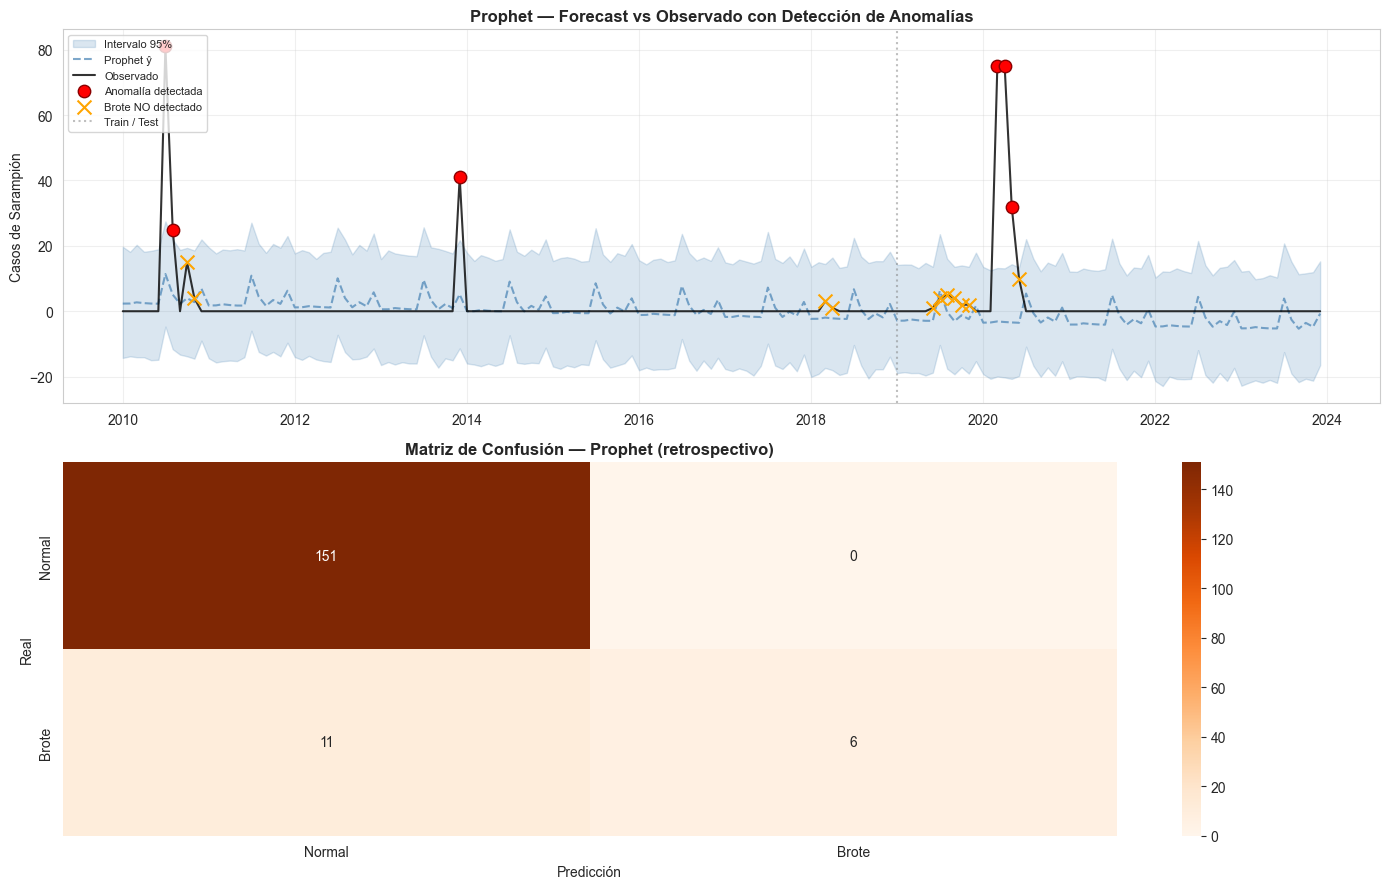

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
axes[0].fill_between(df_raw["fecha"], df_raw["prophet_lower"], df_raw["prophet_upper"],
                     alpha=0.2, color="steelblue", label="Intervalo 95%")
axes[0].plot(df_raw["fecha"], df_raw["prophet_yhat"], color="steelblue",
             ls="--", alpha=0.7, label="Prophet ŷ")
axes[0].plot(df_raw["fecha"], df_raw["casos_sarampion"],
             color="black", alpha=0.8, lw=1.5, label="Observado")
anom_mask = df_raw["prophet_anomaly"] == 1
axes[0].scatter(df_raw.loc[anom_mask, "fecha"], df_raw.loc[anom_mask, "casos_sarampion"],
                color="red", s=80, zorder=5, edgecolors="darkred", label="Anomalía detectada")
missed_p = (df_raw["brote"] == 1) & (df_raw["prophet_anomaly"] == 0)
if missed_p.any():
    axes[0].scatter(df_raw.loc[missed_p, "fecha"], df_raw.loc[missed_p, "casos_sarampion"],
                    color="orange", marker="x", s=100, zorder=5, label="Brote NO detectado")
axes[0].axvline(pd.Timestamp(f"{SPLIT_YEAR}-01-01"), color="gray", ls=":", alpha=0.5, label="Train / Test")
axes[0].set_ylabel("Casos de Sarampión")
axes[0].set_title("Prophet — Forecast vs Observado con Detección de Anomalías", fontweight="bold")
axes[0].legend(fontsize=8, loc="upper left")
axes[0].grid(True, alpha=0.3)

cm_p = confusion_matrix(y_true_full, y_pred_prophet)
sns.heatmap(cm_p, annot=True, fmt="d", cmap="Oranges", ax=axes[1],
            xticklabels=["Normal", "Brote"], yticklabels=["Normal", "Brote"])
axes[1].set_xlabel("Predicción")
axes[1].set_ylabel("Real")
axes[1].set_title("Matriz de Confusión — Prophet", fontweight="bold")

plt.tight_layout()
plt.show()

## 8. Baseline 5: Modelo Bayesiano Jerárquico (Poisson-Gamma)

### Fundamento

El modelo Bayesiano jerárquico combina información previa con los datos observados para estimar la distribución de la tasa de casos por mes. Utiliza el framework conjugado **Poisson-Gamma**

Su enfoque bayesiano permite incorporar conocimiento epidemiológico previo (como la altísima contagiosidad histórica del sarampión) y entrega resultados en forma de probabilidades; esto significa que el modelo no solo predice una tendencia, sino que indica la probabilidad exacta y el riesgo estadístico de que detone un brote basado en caracteristicas como la cobertura de vacunación

In [20]:
global_mean_train = train_raw["casos_sarampion"].mean()
global_var_train  = train_raw["casos_sarampion"].var()

if global_var_train > global_mean_train and global_mean_train > 0:
    beta_0  = global_mean_train / max(global_var_train, 1e-6)
    alpha_0 = global_mean_train * beta_0
else:
    alpha_0, beta_0 = 0.5, 0.5

print("Hiperparámetros del prior Gamma(α₀, β₀):")
print(f"  α₀ = {alpha_0:.4f}")
print(f"  β₀ = {beta_0:.4f}")
print(f"  E[λ] prior = {alpha_0 / beta_0:.3f}")

posteriors_by_month = {}
print(f"\nPosterior por mes (Gamma actualizada con datos de entrenamiento):")
print(f"{'Mes':>4} | {'n_obs':>5} | {'Σy':>5} | {'α_post':>8} | {'β_post':>8} | {'E[λ]_post':>10}")
print("─" * 60)

for mes in range(1, 13):
    month_data = train_raw[train_raw["mes"] == mes]["casos_sarampion"]
    n_m    = len(month_data)
    sum_ym = int(month_data.sum())

    alpha_post = alpha_0 + sum_ym
    beta_post  = beta_0 + n_m

    posteriors_by_month[mes] = (alpha_post, beta_post)
    print(f"{mes:>4} | {n_m:>5} | {sum_ym:>5} | {alpha_post:>8.3f} | {beta_post:>8.3f} | {alpha_post / beta_post:>10.3f}")

Hiperparámetros del prior Gamma(α₀, β₀):
  α₀ = 0.0300
  β₀ = 0.0190
  E[λ] prior = 1.574

Posterior por mes (Gamma actualizada con datos de entrenamiento):
 Mes | n_obs |    Σy |   α_post |   β_post |  E[λ]_post
────────────────────────────────────────────────────────────
   1 |     9 |     0 |    0.030 |    9.019 |      0.003
   2 |     9 |     0 |    0.030 |    9.019 |      0.003
   3 |     9 |     3 |    3.030 |    9.019 |      0.336
   4 |     9 |     1 |    1.030 |    9.019 |      0.114
   5 |     9 |     0 |    0.030 |    9.019 |      0.003
   6 |     9 |     0 |    0.030 |    9.019 |      0.003
   7 |     9 |    81 |   81.030 |    9.019 |      8.984
   8 |     9 |    25 |   25.030 |    9.019 |      2.775
   9 |     9 |     0 |    0.030 |    9.019 |      0.003
  10 |     9 |    15 |   15.030 |    9.019 |      1.666
  11 |     9 |     4 |    4.030 |    9.019 |      0.447
  12 |     9 |    41 |   41.030 |    9.019 |      4.549


In [21]:
#Detección de anomalías
BAYES_ALPHA = 0.05

y_pred_bayes  = np.zeros(len(df_raw), dtype=int)
bayes_pvalues = np.zeros(len(df_raw))

for idx in range(len(df_raw)):
    mes   = int(df_raw.iloc[idx]["mes"])
    y_obs = int(df_raw.iloc[idx]["casos_sarampion"])
    alpha_post, beta_post = posteriors_by_month[mes]

    r = alpha_post
    p = beta_post / (1.0 + beta_post)

    if y_obs > 0:
        p_value = 1.0 - nbinom_dist.cdf(y_obs - 1, r, p)
    else:
        p_value = 1.0

    bayes_pvalues[idx] = p_value
    y_pred_bayes[idx]  = 1 if p_value < BAYES_ALPHA else 0

bayes_scores = 1.0 - bayes_pvalues

#Evaluación
res_bayes = evaluar_detector(y_true_full, y_pred_bayes,
                             f"Bayesiano Jerárquico (α={BAYES_ALPHA})",
                             y_score=bayes_scores)
all_results.append(res_bayes)


  Bayesiano Jerárquico (α=0.05)
  Precision:         1.000
  Recall:            0.706
  F1-Score:          0.828
  F2-Score:          0.750
  AUC-PR:            1.000
  Brotes detectados: 12 / 17
  Falsas alarmas:    0


**Evaluación Temporal**

In [22]:
test_mask_bayes = df_raw["anio"] >= SPLIT_YEAR
y_test_bayes = df_raw.loc[test_mask_bayes, "brote"].values
y_pred_bayes_test = y_pred_bayes[test_mask_bayes.values]

if y_test_bayes.sum() > 0:
    bayes_scores_test = bayes_scores[test_mask_bayes.values]
    evaluar_detector(y_test_bayes, y_pred_bayes_test,
                     "Bayesiano Jerárquico", y_score=bayes_scores_test)
else:
    fa_bayes_test = int(y_pred_bayes_test.sum())
    print(f"\n  Bayesiano (test {SPLIT_YEAR}–2023): Sin brotes reales en test.")
    print(f"  Falsas alarmas en test: {fa_bayes_test}")


  Bayesiano Jerárquico
  Precision:         1.000
  Recall:            0.600
  F1-Score:          0.750
  F2-Score:          0.652
  AUC-PR:            1.000
  Brotes detectados: 6 / 10
  Falsas alarmas:    0


**Barrido de umbrales α — Bayesiano Jerárquico**

In [23]:
alphas_sweep = [0.01, 0.025, 0.05, 0.10, 0.15, 0.20, 0.30]
rows_bayes = []
for a in alphas_sweep:
    yp = (bayes_pvalues < a).astype(int)
    rows_bayes.append({
        "α": a,
        "Precision": round(precision_score(y_true_full, yp, zero_division=0), 3),
        "Recall":    round(recall_score(y_true_full, yp, zero_division=0), 3),
        "F1":        round(f1_score(y_true_full, yp, zero_division=0), 3),
        "F2":        round(fbeta_score(y_true_full, yp, beta=2, zero_division=0), 3),
        "Detectados": int(yp[y_true_full == 1].sum()),
        "Falsas_alarmas": int(yp[y_true_full == 0].sum()),
    })

df_thresh_bayes = pd.DataFrame(rows_bayes)
display(df_thresh_bayes)

,α,Precision,Recall,F1,F2,Detectados,Falsas_alarmas
0,0.010,1.0,0.706,0.828,0.750,12,0
1,0.025,1.0,0.706,0.828,0.750,12,0
2,0.050,1.0,0.706,0.828,0.750,12,0
3,0.100,1.0,0.765,0.867,0.802,13,0
4,0.150,1.0,0.824,0.903,0.854,14,0
5,0.200,1.0,0.882,0.938,0.904,15,0
6,0.300,1.0,0.882,0.938,0.904,15,0


**Visualización Bayesiano Jerárquico**

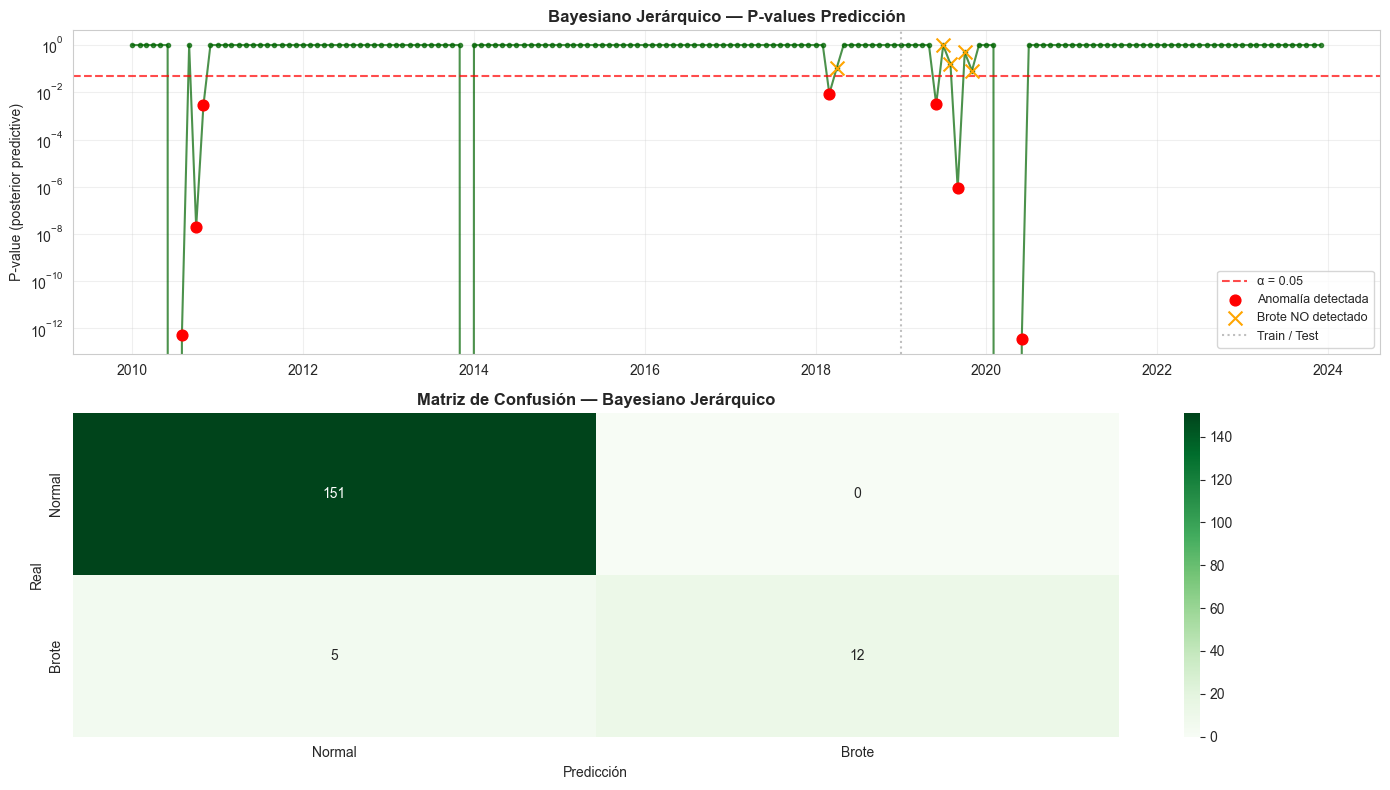

In [24]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(df_raw["fecha"], bayes_pvalues, color="darkgreen", alpha=0.7, marker="o", ms=3)
axes[0].axhline(BAYES_ALPHA, color="red", ls="--", alpha=0.7, label=f"α = {BAYES_ALPHA}")

det_bayes_idx = np.where(y_pred_bayes == 1)[0]
axes[0].scatter(df_raw.iloc[det_bayes_idx]["fecha"], bayes_pvalues[det_bayes_idx],
                color="red", s=60, zorder=5, label="Anomalía detectada")
brote_idx = np.where(y_true_full == 1)[0]
missed_bayes = [i for i in brote_idx if y_pred_bayes[i] == 0]
if missed_bayes:
    axes[0].scatter(df_raw.iloc[missed_bayes]["fecha"], bayes_pvalues[missed_bayes],
                    color="orange", marker="x", s=100, zorder=5, label="Brote NO detectado")
axes[0].axvline(pd.Timestamp(f"{SPLIT_YEAR}-01-01"), color="gray", ls=":", alpha=0.5, label="Train / Test")
axes[0].set_ylabel("P-value (posterior predictive)")
axes[0].set_title("Bayesiano Jerárquico — P-values Predicción", fontweight="bold")
axes[0].set_yscale("log")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

cm_bayes = confusion_matrix(y_true_full, y_pred_bayes)
sns.heatmap(cm_bayes, annot=True, fmt="d", cmap="Greens", ax=axes[1],
            xticklabels=["Normal", "Brote"], yticklabels=["Normal", "Brote"])
axes[1].set_xlabel("Predicción")
axes[1].set_ylabel("Real")
axes[1].set_title("Matriz de Confusión — Bayesiano Jerárquico", fontweight="bold")

plt.tight_layout()
plt.show()

## 9. Baseline 6: Modelo de Espacio de Estados (State Space)

### Fundamento

El modelo de **Componentes No Observados** (Unobserved Components Model, UCM) descompone la serie temporal en componentes estructurales latentes.

**Detección de anomalías con State Space:**
El modelo genera intervalos de predicción. Un mes es **anómalo** si el valor observado excede el límite superior del intervalo de confianza al 95%

**Configuración:**
- Se ajusta sobre datos de entrenamiento (2010–2018).
- Nivel local + estacionalidad estocástica de 12 meses.
- Implementación via `statsmodels.tsa.statespace.structural.UnobservedComponents`.

In [25]:
train_series_ss = (train_raw
                   .set_index("fecha")["casos_sarampion"]
                   .asfreq("MS")
                   .fillna(0))

print(f"Serie de entrenamiento: {len(train_series_ss)} meses")
print(f"  Rango: {train_series_ss.index.min().date()} → {train_series_ss.index.max().date()}")

uc_model = UnobservedComponents(
    train_series_ss,
    level="local level",
    seasonal=12,
    stochastic_seasonal=True,
)
uc_result = uc_model.fit(disp=False, maxiter=500)

#Predicciones(train)
in_sample_pred = uc_result.get_prediction(start=0, end=len(train_series_ss) - 1)
in_sample_ci   = in_sample_pred.conf_int(alpha=0.05)

#Predicciones(test)
n_test_ss = len(test_raw)
oos_pred = uc_result.get_forecast(steps=n_test_ss)
oos_ci   = oos_pred.conf_int(alpha=0.05)

#Predicciones combinadas
upper_train_ss = in_sample_ci.iloc[:, 1].values
upper_test_ss  = oos_ci.iloc[:, 1].values
upper_full_ss  = np.concatenate([upper_train_ss, upper_test_ss])

yhat_train_ss = in_sample_pred.predicted_mean.values
yhat_test_ss  = oos_pred.predicted_mean.values
yhat_full_ss  = np.concatenate([yhat_train_ss, yhat_test_ss])

lower_train_ss = in_sample_ci.iloc[:, 0].values
lower_test_ss  = oos_ci.iloc[:, 0].values
lower_full_ss  = np.concatenate([lower_train_ss, lower_test_ss])

print(f"\nPredicciones generadas: {len(upper_full_ss)} meses (train: {len(upper_train_ss)}, test: {len(upper_test_ss)})")

Serie de entrenamiento: 108 meses
  Rango: 2010-01-01 → 2018-12-01

Predicciones generadas: 168 meses (train: 108, test: 60)


In [26]:
y_obs_ss = df_raw["casos_sarampion"].values
y_pred_ss = (y_obs_ss > upper_full_ss).astype(int)

residuals_ss = y_obs_ss - yhat_full_ss
ss_range = np.maximum(upper_full_ss - yhat_full_ss, 1e-6)
ss_scores = residuals_ss / ss_range

#Evaluación
res_ss = evaluar_detector(y_true_full, y_pred_ss,
                          "Espacio de estados",
                          y_score=ss_scores)
all_results.append(res_ss)


  Espacio de estados
  Precision:         1.000
  Recall:            0.235
  F1-Score:          0.381
  F2-Score:          0.278
  AUC-PR:            0.630
  Brotes detectados: 4 / 17
  Falsas alarmas:    0


**Evaluación temporal**

In [27]:
test_mask_ss = df_raw["anio"] >= SPLIT_YEAR
y_test_ss_vals = df_raw.loc[test_mask_ss, "brote"].values
y_pred_ss_test = y_pred_ss[test_mask_ss.values]

if y_test_ss_vals.sum() > 0:
    ss_scores_test = ss_scores[test_mask_ss.values]
    evaluar_detector(y_test_ss_vals, y_pred_ss_test,
                     "Espacio de estados(test)", y_score=ss_scores_test)
else:
    fa_ss_test = int(y_pred_ss_test.sum())
    print(f"\n  State Space (test {SPLIT_YEAR}–2023): Sin brotes reales en test.")
    print(f"  Falsas alarmas en test: {fa_ss_test}")


  Espacio de estados(test)
  Precision:         1.000
  Recall:            0.300
  F1-Score:          0.462
  F2-Score:          0.349
  AUC-PR:            0.854
  Brotes detectados: 3 / 10
  Falsas alarmas:    0


**Visualización**

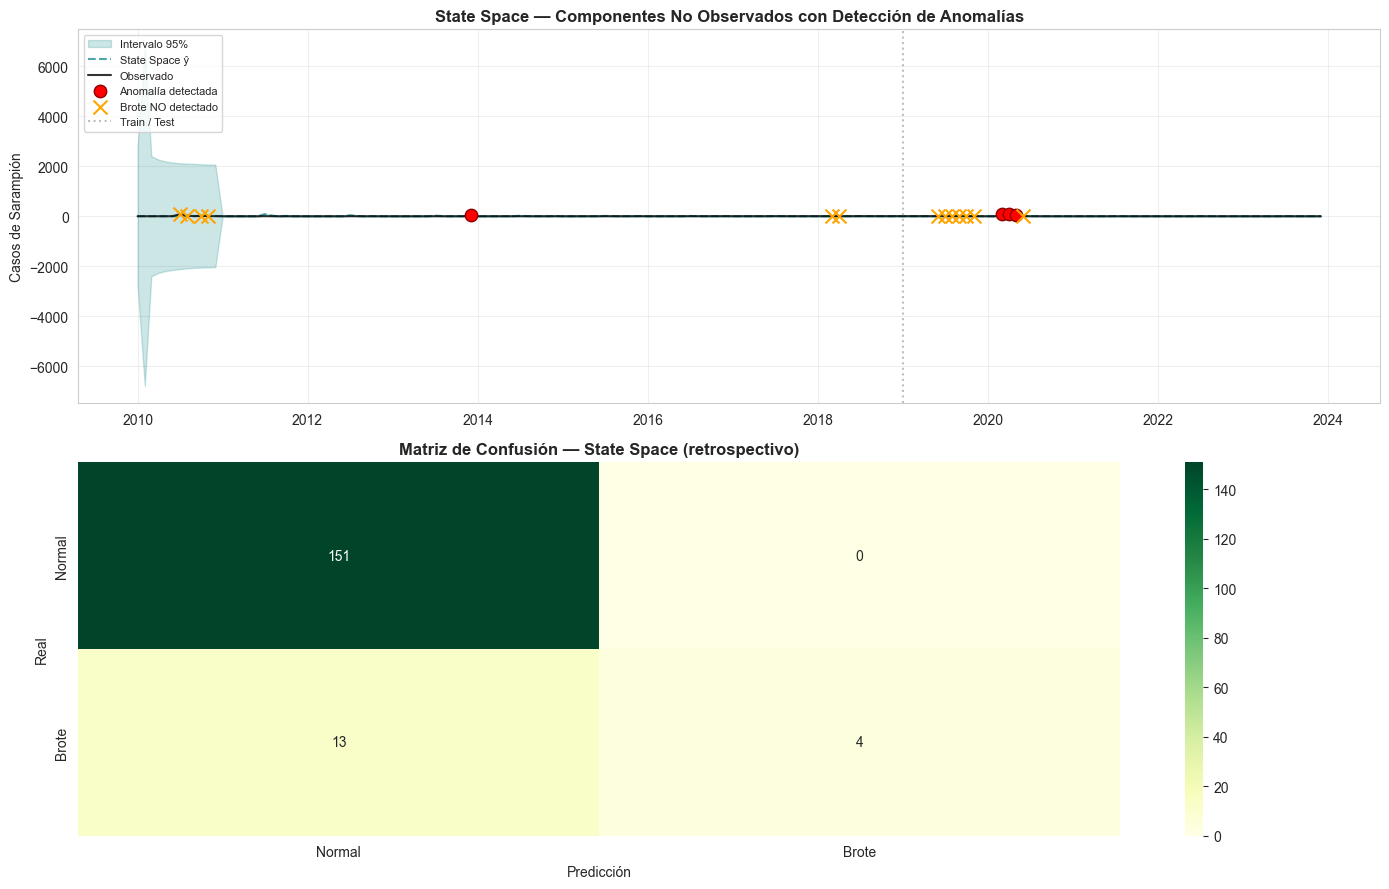

In [28]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

axes[0].fill_between(df_raw["fecha"], lower_full_ss, upper_full_ss,
                     alpha=0.2, color="teal", label="Intervalo 95%")
axes[0].plot(df_raw["fecha"], yhat_full_ss, color="teal",
             ls="--", alpha=0.7, label="State Space ŷ")
axes[0].plot(df_raw["fecha"], df_raw["casos_sarampion"],
             color="black", alpha=0.8, lw=1.5, label="Observado")

det_ss_idx = np.where(y_pred_ss == 1)[0]
axes[0].scatter(df_raw.iloc[det_ss_idx]["fecha"],
                df_raw.iloc[det_ss_idx]["casos_sarampion"],
                color="red", s=80, zorder=5, edgecolors="darkred", label="Anomalía detectada")
brote_ss_idx = np.where(y_true_full == 1)[0]
missed_ss = [i for i in brote_ss_idx if y_pred_ss[i] == 0]
if missed_ss:
    axes[0].scatter(df_raw.iloc[missed_ss]["fecha"],
                    df_raw.iloc[missed_ss]["casos_sarampion"],
                    color="orange", marker="x", s=100, zorder=5, label="Brote NO detectado")
axes[0].axvline(pd.Timestamp(f"{SPLIT_YEAR}-01-01"), color="gray", ls=":", alpha=0.5, label="Train / Test")
axes[0].set_ylabel("Casos de Sarampión")
axes[0].set_title("State Space — Componentes No Observados con Detección de Anomalías", fontweight="bold")
axes[0].legend(fontsize=8, loc="upper left")
axes[0].grid(True, alpha=0.3)

cm_ss = confusion_matrix(y_true_full, y_pred_ss)
sns.heatmap(cm_ss, annot=True, fmt="d", cmap="YlGn", ax=axes[1],
            xticklabels=["Normal", "Brote"], yticklabels=["Normal", "Brote"])
axes[1].set_xlabel("Predicción")
axes[1].set_ylabel("Real")
axes[1].set_title("Matriz de Confusión — State Space", fontweight="bold")

plt.tight_layout()
plt.show()

**Descomposición de los componentes**

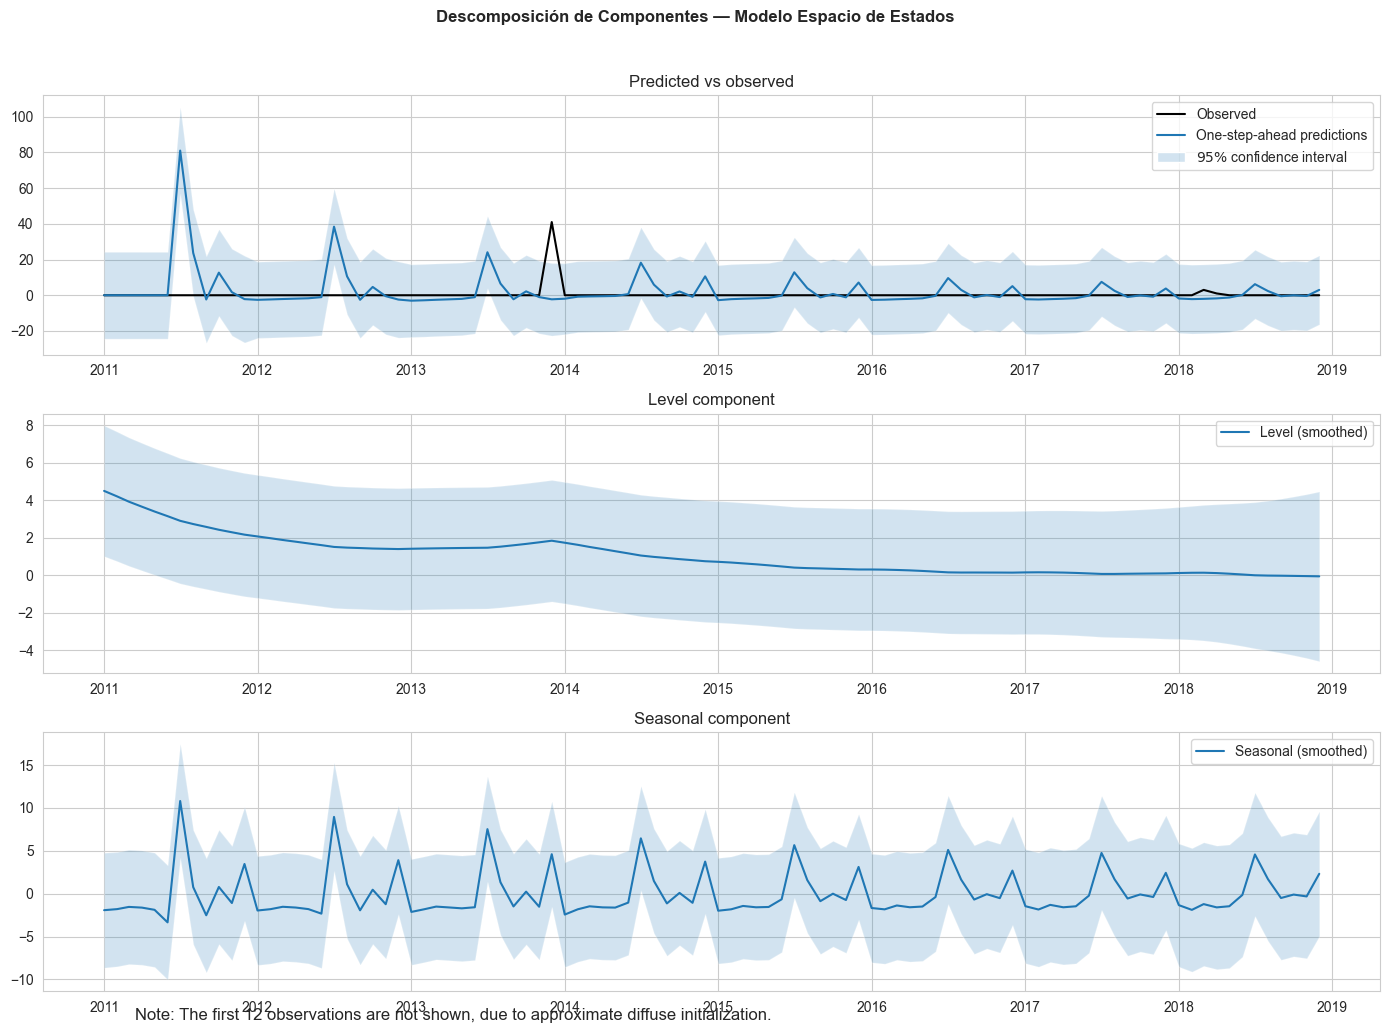

In [29]:
fig = uc_result.plot_components(figsize=(14, 10))
plt.suptitle("Descomposición de Componentes — Modelo Espacio de Estados", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 10. Baselines 7 y 8: Modelos de Conteo — Poisson GLM y Negative Binomial GLM

### Fundamento

Los modelos lineales generalizados (GLM) para datos de conteo son una alternativa natural para modelar el número de casos de sarampión.

Se quiere predecir  un numero de casos por mes. Ese numero es un conteo (0, 1, 2, ...) y no una variable continua. Por eso evaluaremos el rendimiento de  modelos de conteo.

- **Poisson**: es el modelo base para conteos. Supone que la variabilidad es similar al promedio. Funciona bien cuando los datos no tienen demasiados ceros extra ni picos extremos.
- **Negative Binomial**: es una version mas flexible. Mantiene el enlace log, pero permite mas variabilidad que el promedio. En series con brotes y muchos ceros, suele ajustarse mejor.

Adicionalmente se reportan métricas de conteo nativas (MAE, RMSE, Poisson Deviance) para contexto.

In [30]:
df_glm = df_fe.copy()
target = "casos_sarampion"

df_glm["casos_lag_1m"]  = df_glm[target].shift(1)
df_glm["casos_lag_12m"] = df_glm[target].shift(12)

#Partición temporal
train_glm = df_glm[df_glm["anio"] < SPLIT_YEAR].copy()
test_glm  = df_glm[df_glm["anio"] >= SPLIT_YEAR].copy()
full_glm = df_glm.copy()

# Selección de covariables
glm_exclude = {"anio", "mes", "fecha", target, "brote"}
num_cols = df_glm.select_dtypes(include=[np.number]).columns.tolist()
glm_feature_cols = [c for c in num_cols if c not in glm_exclude]

for lag_col in ["casos_lag_1m", "casos_lag_12m"]:
    if lag_col not in glm_feature_cols:
        glm_feature_cols.append(lag_col)

train_x_glm = sm.add_constant(train_glm[glm_feature_cols].fillna(0), has_constant="add")
test_x_glm  = sm.add_constant(test_glm[glm_feature_cols].fillna(0), has_constant="add")
full_x_glm  = sm.add_constant(full_glm[glm_feature_cols].fillna(0), has_constant="add")

train_y_glm = train_glm[target].copy()
test_y_glm  = test_glm[target].copy()
full_y_glm  = full_glm[target].copy()

print(f"Features GLM: {len(glm_feature_cols)}")
print(f"Train: {len(train_glm)} meses | Test: {len(test_glm)} meses")
print(f"Brotes train: {(train_glm['brote']==1).sum()} | Brotes test: {(test_glm['brote']==1).sum()}")

Features GLM: 24
Train: 108 meses | Test: 60 meses
Brotes train: 7 | Brotes test: 10


**Ajuste del modelo de Poisson y binomial**

In [31]:
poisson_model = sm.GLM(train_y_glm, train_x_glm, family=sm.families.Poisson()).fit()

alpha_grid = [0.1, 0.3, 0.5, 1.0, 2.0]
nb_models = []
for a in alpha_grid:
    nb = sm.GLM(train_y_glm, train_x_glm, family=sm.families.NegativeBinomial(alpha=a)).fit()
    nb_models.append((a, nb.aic, nb))
best_alpha, best_aic, nb_model = sorted(nb_models, key=lambda x: x[1])[0]

print(f"Mejor alpha NB por AIC: {best_alpha} | AIC: {best_aic:.2f}")

poisson_dispersion = poisson_model.pearson_chi2 / poisson_model.df_resid
print(f"\nDispersión Poisson (pearson_chi2/df_resid): {poisson_dispersion:.2f}")
print(f"  → {'Sobredispersión detectada' if poisson_dispersion > 1 else 'Sin sobredispersión significativa'}")

print(f"\nPoisson AIC: {poisson_model.aic:.2f}")
print(f"NegBin  AIC: {nb_model.aic:.2f}")

Mejor alpha NB por AIC: 0.1 | AIC: 66.16

Dispersión Poisson (pearson_chi2/df_resid): 0.06
  → Sin sobredispersión significativa

Poisson AIC: 59.50
NegBin  AIC: 66.16


In [32]:
def poisson_deviance(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.clip(np.asarray(y_pred), 1e-9, None)
    term = np.where(y_true == 0, -y_pred, y_true * np.log(y_true / y_pred) - (y_true - y_pred))
    return 2 * np.mean(term)

def eval_count_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return {
        "MAE": np.mean(np.abs(y_true - y_pred)),
        "RMSE": np.sqrt(np.mean((y_true - y_pred) ** 2)),
        "Poisson_Deviance": poisson_deviance(y_true, y_pred),
    }

# Predicciones en test
pred_pois_test = poisson_model.predict(test_x_glm)
pred_nb_test   = nb_model.predict(test_x_glm)

print("Métricas de conteo")
print(f"Poisson:  {eval_count_metrics(test_y_glm, pred_pois_test)}")
print(f"NegBin:   {eval_count_metrics(test_y_glm, pred_nb_test)}")

Métricas de conteo
Poisson:  {'MAE': 49100.34785125596, 'RMSE': 377099.3128988314, 'Poisson_Deviance': 98157.90463047843}
NegBin:   {'MAE': 44638.69538326021, 'RMSE': 342640.89886385255, 'Poisson_Deviance': 89235.90390447804}


**Evaluación Poisson GLM**

In [33]:
pred_pois_full = poisson_model.predict(full_x_glm)
pred_nb_full   = nb_model.predict(full_x_glm)

resid_pois = (full_y_glm.values - pred_pois_full) / np.sqrt(np.maximum(pred_pois_full, 1e-9))

GLM_RESID_THRESHOLD = 2.0
y_pred_pois = (resid_pois > GLM_RESID_THRESHOLD).astype(int)

y_full_glm = full_glm["brote"].values

res_pois = evaluar_detector(y_full_glm, y_pred_pois,
                            f"Poisson GLM (residuo > {GLM_RESID_THRESHOLD})",
                            y_score=resid_pois)
all_results.append(res_pois)


  Poisson GLM (residuo > 2.0)
  Precision:         1.000
  Recall:            0.294
  F1-Score:          0.455
  F2-Score:          0.342
  AUC-PR:            0.571
  Brotes detectados: 5 / 17
  Falsas alarmas:    0


**Evaluación Binomial Negativa con residuos de Pearson**

In [34]:
nb_var = pred_nb_full + best_alpha * pred_nb_full**2
resid_nb = (full_y_glm.values - pred_nb_full) / np.sqrt(np.maximum(nb_var, 1e-9))
y_pred_nb = (resid_nb > GLM_RESID_THRESHOLD).astype(int)

res_nb = evaluar_detector(y_full_glm, y_pred_nb,
                          f"NegBin GLM (residuo > {GLM_RESID_THRESHOLD})",
                          y_score=resid_nb)
all_results.append(res_nb)


  NegBin GLM (residuo > 2.0)
  Precision:         1.000
  Recall:            0.235
  F1-Score:          0.381
  F2-Score:          0.278
  AUC-PR:            0.569
  Brotes detectados: 4 / 17
  Falsas alarmas:    0


**Evaluación Temporal Poisson y Binomial Negativa**

In [35]:
test_mask_glm = full_glm["anio"] >= SPLIT_YEAR
y_test_glm_vals = full_glm.loc[test_mask_glm, "brote"].values

y_pred_pois_test = y_pred_pois[test_mask_glm.values]
y_pred_nb_test   = y_pred_nb[test_mask_glm.values]

if y_test_glm_vals.sum() > 0:
    evaluar_detector(y_test_glm_vals, y_pred_pois_test, "Poisson GLM (test)")
    evaluar_detector(y_test_glm_vals, y_pred_nb_test, "NegBin GLM (test)")
else:
    print(f"\n  Poisson GLM (test): Falsas alarmas = {int(y_pred_pois_test.sum())}")
    print(f"  NegBin GLM (test):  Falsas alarmas = {int(y_pred_nb_test.sum())}")


  Poisson GLM (test)
  Precision:         1.000
  Recall:            0.400
  F1-Score:          0.571
  F2-Score:          0.455
  Brotes detectados: 4 / 10
  Falsas alarmas:    0

  NegBin GLM (test)
  Precision:         1.000
  Recall:            0.300
  F1-Score:          0.462
  F2-Score:          0.349
  Brotes detectados: 3 / 10
  Falsas alarmas:    0


**Visualización**

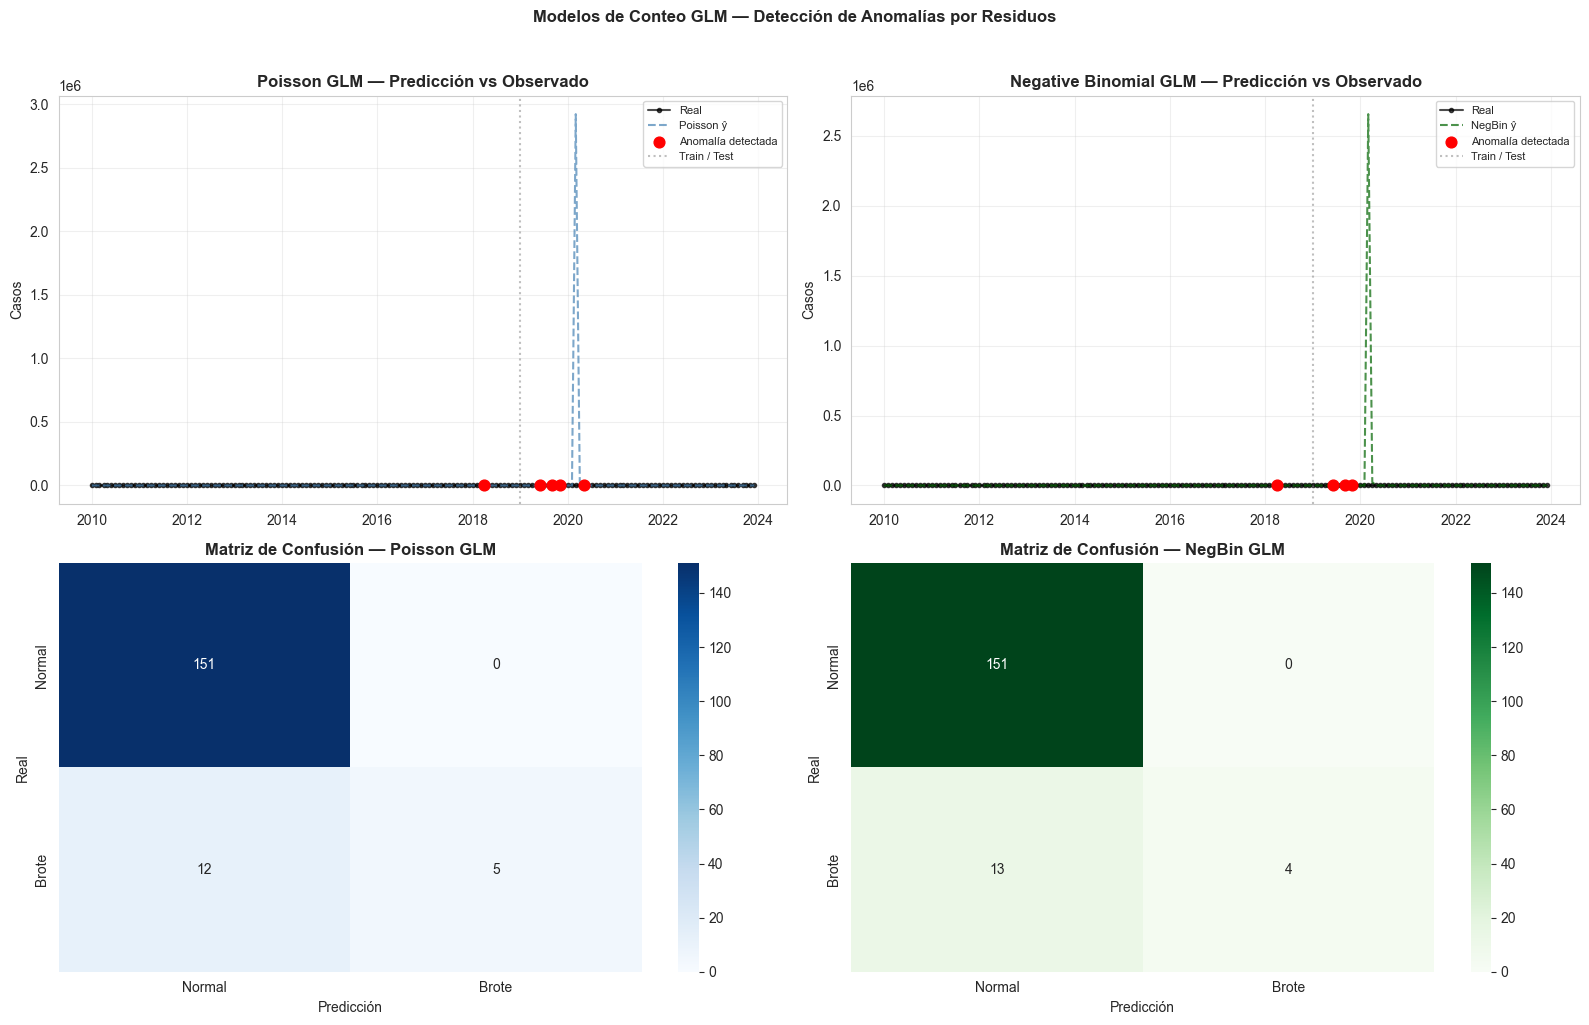

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].plot(full_glm["fecha"], full_y_glm, label="Real", marker="o", ms=3, color="black", alpha=0.7)
axes[0, 0].plot(full_glm["fecha"], pred_pois_full, label="Poisson ŷ", ls="--", color="steelblue", alpha=0.7)
det_pois_idx = np.where(y_pred_pois == 1)[0]
if len(det_pois_idx):
    axes[0, 0].scatter(full_glm.iloc[det_pois_idx]["fecha"], full_y_glm.values[det_pois_idx],
                        color="red", s=60, zorder=5, label="Anomalía detectada")
axes[0, 0].axvline(pd.Timestamp(f"{SPLIT_YEAR}-01-01"), color="gray", ls=":", alpha=0.5, label="Train / Test")
axes[0, 0].set_title("Poisson GLM — Predicción vs Observado", fontweight="bold")
axes[0, 0].set_ylabel("Casos")
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(full_glm["fecha"], full_y_glm, label="Real", marker="o", ms=3, color="black", alpha=0.7)
axes[0, 1].plot(full_glm["fecha"], pred_nb_full, label="NegBin ŷ", ls="--", color="darkgreen", alpha=0.7)
det_nb_idx = np.where(y_pred_nb == 1)[0]
if len(det_nb_idx):
    axes[0, 1].scatter(full_glm.iloc[det_nb_idx]["fecha"], full_y_glm.values[det_nb_idx],
                        color="red", s=60, zorder=5, label="Anomalía detectada")
axes[0, 1].axvline(pd.Timestamp(f"{SPLIT_YEAR}-01-01"), color="gray", ls=":", alpha=0.5, label="Train / Test")
axes[0, 1].set_title("Negative Binomial GLM — Predicción vs Observado", fontweight="bold")
axes[0, 1].set_ylabel("Casos")
axes[0, 1].legend(fontsize=8)
axes[0, 1].grid(True, alpha=0.3)

cm_pois = confusion_matrix(y_full_glm, y_pred_pois)
sns.heatmap(cm_pois, annot=True, fmt="d", cmap="Blues", ax=axes[1, 0],
            xticklabels=["Normal", "Brote"], yticklabels=["Normal", "Brote"])
axes[1, 0].set_xlabel("Predicción")
axes[1, 0].set_ylabel("Real")
axes[1, 0].set_title("Matriz de Confusión — Poisson GLM", fontweight="bold")

cm_nb = confusion_matrix(y_full_glm, y_pred_nb)
sns.heatmap(cm_nb, annot=True, fmt="d", cmap="Greens", ax=axes[1, 1],
            xticklabels=["Normal", "Brote"], yticklabels=["Normal", "Brote"])
axes[1, 1].set_xlabel("Predicción")
axes[1, 1].set_ylabel("Real")
axes[1, 1].set_title("Matriz de Confusión — NegBin GLM", fontweight="bold")

plt.suptitle("Modelos de Conteo GLM — Detección de Anomalías por Residuos", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 11. Baseline 9: Isolation Forest

### Fundamento

Isolation Forest aísla observaciones mediante particiones aleatorias recursivas del espacio de características. Las anomalías, al ser escasas y diferentes, requieren **menos particiones** para ser aisladas, lo que se traduce en **caminos más cortos** en los árboles → mayor probabilidad de anomalía.

**Ventajas para este problema:**
- **Multivariado**: utiliza las 12+ características seleccionadas en el Avance 2 (vacunación, temporalidad, lags, tendencias).
- **No supervisado**: no requiere etiquetas de brote para el entrenamiento.
- **Robusto** ante distribuciones no normales y outliers.

**Hiperparámetros clave:**
- `contamination`: proporción esperada de anomalías, fijada en la proporción observada de brotes en el set de entrenamiento.
- `n_estimators`: número de árboles de aislamiento (200).

In [37]:
exclude_cols = {"fecha", "anio", "mes", "casos_sarampion", "brote"}
feature_cols = [c for c in df_fe.columns if c not in exclude_cols]

X_train_if = train_fe[feature_cols].values
X_test_if  = test_fe[feature_cols].values
X_full_if  = df_fe[feature_cols].values

y_train_if = train_fe["brote"].values
y_test_if  = test_fe["brote"].values
y_full_if  = df_fe["brote"].values

contamination_rate = max(y_train_if.mean(), 0.01)

print(f"Features utilizadas: {len(feature_cols)}")
print(f"Contamination rate:  {contamination_rate:.3f}")
print(f"\nFeatures:\n{feature_cols}")

Features utilizadas: 22
Contamination rate:  0.065

Features:
['tasa_casos_por_millon_dosis', 'casos_sarampion_log', 'casos_ytd_log', 'casos_rolling_mean_3m_log', 'casos_rolling_mean_6m_log', 'dosis_lag_14m_log', 'dosis_lag_13m_log', 'total_dosis_log', 'dosis_rolling_mean_3m_log', 'dosis_rolling_std_3m_log', 'PCA_1', 'PCA_2', 'PCA_3', 'PCA_4', 'PCA_5', 'PCA_6', 'PCA_7', 'FA_1', 'FA_2', 'FA_3', 'FA_4', 'FA_5']


**Evaluación**

In [38]:
from sklearn.ensemble import IsolationForest

#Entrenamiento
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=contamination_rate,
    random_state=42,
    n_jobs=-1,
)
iso_forest.fit(X_train_if)

#Predicciones
scores_full_if = iso_forest.decision_function(X_full_if)
scores_test_if = iso_forest.decision_function(X_test_if)

preds_full = iso_forest.predict(X_full_if)
y_pred_if_full = np.where(preds_full == -1, 1, 0)

preds_test = iso_forest.predict(X_test_if)
y_pred_if_test = np.where(preds_test == -1, 1, 0)

res_if = evaluar_detector(y_full_if, y_pred_if_full,
                          "Isolation Forest ",
                          y_score=-scores_full_if)
all_results.append(res_if)


  Isolation Forest 
  Precision:         0.619
  Recall:            0.765
  F1-Score:          0.684
  F2-Score:          0.730
  AUC-PR:            0.782
  Brotes detectados: 13 / 17
  Falsas alarmas:    8


**Evaluación temporal**

In [39]:
if y_test_if.sum() > 0:
    res_if_test = evaluar_detector(y_test_if, y_pred_if_test,
                                   "Isolation Forest (test)",
                                   y_score=-scores_test_if)
else:
    fa_test = int(y_pred_if_test.sum())
    print(f"\n  Isolation Forest (test {SPLIT_YEAR}–2023): Sin brotes reales en test.")
    print(f"  Falsas alarmas en test: {fa_test}")


  Isolation Forest (test)
  Precision:         0.571
  Recall:            0.800
  F1-Score:          0.667
  F2-Score:          0.741
  AUC-PR:            0.856
  Brotes detectados: 8 / 10
  Falsas alarmas:    6


### 11.1 Importancia de Características — Isolation Forest

¿Se puede determinar la importancia de las características? Sí: se usa **importancia por permutación**, que mide cuánto empeora el F2-Score al aleatorizar cada feature. Las features cuya permutación causa mayor pérdida de rendimiento son las más relevantes para el detector.

In [40]:
np.random.seed(42)
base_f2 = fbeta_score(y_full_if, y_pred_if_full, beta=2, zero_division=0)

N_REPEATS = 20
importances = {}

for col_idx, col_name in enumerate(feature_cols):
    deltas = []
    for _ in range(N_REPEATS):
        X_perm = X_full_if.copy()
        X_perm[:, col_idx] = np.random.permutation(X_perm[:, col_idx])
        preds_perm = iso_forest.predict(X_perm)
        y_perm = np.where(preds_perm == -1, 1, 0)
        f2_perm = fbeta_score(y_full_if, y_perm, beta=2, zero_division=0)
        deltas.append(base_f2 - f2_perm)
    importances[col_name] = np.mean(deltas)

imp_df = (pd.Series(importances)
          .sort_values(ascending=False)
          .reset_index()
          .rename(columns={"index": "Feature", 0: "ΔF2 (importancia)"}))

print(f"F2 base del modelo: {base_f2:.3f}\n")
print("Importancia por permutación (ΔF2):")
display(imp_df)

F2 base del modelo: 0.730

Importancia por permutación (ΔF2):


,Feature,ΔF2 (importancia)
0,tasa_casos_por_millon_dosis,0.096087
1,FA_1,0.094017
2,casos_sarampion_log,0.093630
3,FA_2,0.091176
4,PCA_4,0.084818
5,PCA_1,0.074313
6,total_dosis_log,0.051317
7,PCA_3,0.036513
8,dosis_lag_13m_log,0.032618
9,PCA_2,0.031265


**Visualización de importancia de características**

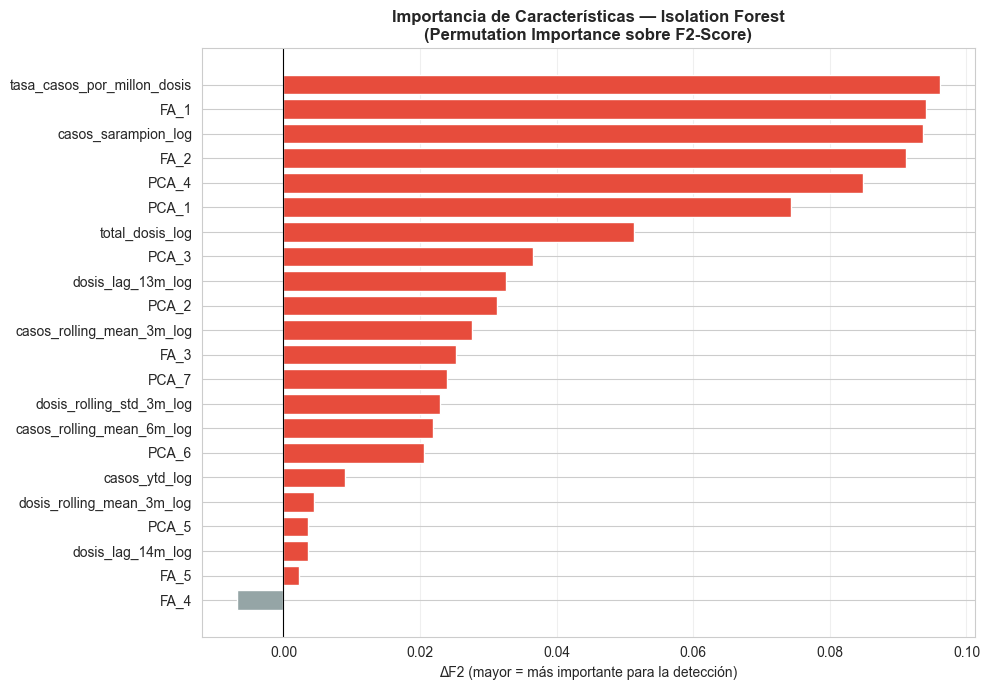

In [41]:
fig, ax = plt.subplots(figsize=(10, 7))
colors = ["#E74C3C" if v > 0.001 else "#3498DB" if v > 0 else "#95A5A6"
          for v in imp_df["ΔF2 (importancia)"]]
ax.barh(imp_df["Feature"][::-1], imp_df["ΔF2 (importancia)"][::-1], color=colors[::-1])
ax.set_xlabel("ΔF2 (mayor = más importante para la detección)")
ax.set_title("Importancia de Características — Isolation Forest\n(Permutation Importance sobre F2-Score)",
             fontweight="bold")
ax.axvline(0, color="black", lw=0.8)
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

**Características importantes**

In [42]:
top_feats = imp_df[imp_df["ΔF2 (importancia)"] > 0.001]["Feature"].tolist()
print(f"\nFeatures con importancia positiva significativa: {len(top_feats)}")
if top_feats:
    print(f"\n{top_feats}")


Features con importancia positiva significativa: 21

['tasa_casos_por_millon_dosis', 'FA_1', 'casos_sarampion_log', 'FA_2', 'PCA_4', 'PCA_1', 'total_dosis_log', 'PCA_3', 'dosis_lag_13m_log', 'PCA_2', 'casos_rolling_mean_3m_log', 'FA_3', 'PCA_7', 'dosis_rolling_std_3m_log', 'casos_rolling_mean_6m_log', 'PCA_6', 'casos_ytd_log', 'dosis_rolling_mean_3m_log', 'PCA_5', 'dosis_lag_14m_log', 'FA_5']


## 10. Comparación de Todos los Modelos

Se comparan los 9 modelos en evaluación retrospectiva sobre el dataset completo.

Para detectores de anomalías, el sub/sobreajuste se manifiesta de forma distinta:

| Problema | Señal | Consecuencia |
|----------|-------|-------------|
| **Subajuste** | Recall bajo, muchos brotes no detectados | El modelo es demasiado conservador |
| **Sobreajuste** | Muchas falsas alarmas en test, rendimiento mucho mejor en train que en test | El modelo memoriza el ruido del entrenamiento |

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if "all_results" not in globals() or len(all_results) == 0:
    raise ValueError("No hay resultados en all_results. Asegúrate de correr las celdas de modelos antes.")

df_comp = pd.DataFrame(all_results).copy()

sort_key = "F2" if "F2" in df_comp.columns else df_comp.columns[0]
df_comp = df_comp.sort_values(sort_key, ascending=False).reset_index(drop=True)

cols_show = [
    "Modelo", "Precision", "Recall", "F1", "F2", "AUC-PR",
    "Falsas_alarmas",
    "Episodios_reales", "Episodios_detectados", "Delay_promedio"
]
cols_show = [c for c in cols_show if c in df_comp.columns]

print("═" * 110)
print("  COMPARACIÓN — Evaluación retrospectiva (serie completa)")
print("═" * 110)
display(df_comp[cols_show])


══════════════════════════════════════════════════════════════════════════════════════════════════════════════
  COMPARACIÓN — Evaluación retrospectiva (serie completa)
══════════════════════════════════════════════════════════════════════════════════════════════════════════════


,Modelo,Precision,Recall,F1,F2,AUC-PR,Falsas_alarmas
0,Z-Score Global (z > 0.0),1.000,0.882,0.938,0.904,1.000,0
1,Z-Score Rolling 12m (z > 0.0),1.000,0.846,0.917,0.873,0.958,0
2,Bayesiano Jerárquico (α=0.05),1.000,0.706,0.828,0.750,1.000,0
3,Isolation Forest,0.619,0.765,0.684,0.730,0.782,8
4,Holt-Winters resid > 0.50σ,0.317,0.765,0.448,0.596,0.687,28
5,SARIMA resid > 0.50σ,1.000,0.529,0.692,0.584,1.000,0
6,Prophet,1.000,0.353,0.522,0.405,0.717,0
7,Poisson GLM (residuo > 2.0),1.000,0.294,0.455,0.342,0.571,0
8,Espacio de estados,1.000,0.235,0.381,0.278,0.630,0
9,NegBin GLM (residuo > 2.0),1.000,0.235,0.381,0.278,0.569,0


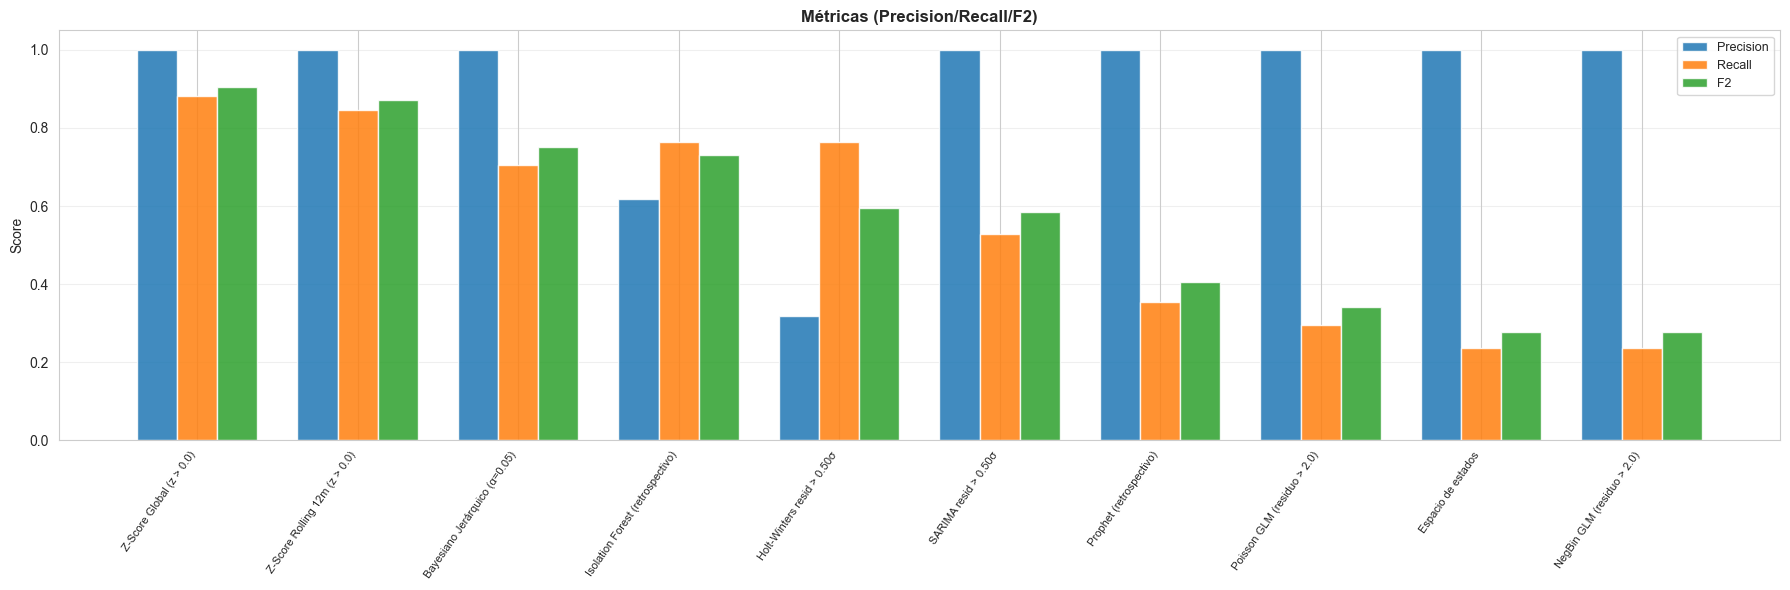

In [44]:
df_plot = df_comp.copy()
for c in ["Precision", "Recall", "F1", "F2", "AUC-PR", "Delay_promedio", "Episodios_detectados", "Episodios_reales"]:
    if c in df_plot.columns:
        df_plot[c] = pd.to_numeric(df_plot[c], errors="coerce")

modelos = df_plot["Modelo"].values
x = np.arange(len(modelos))

fig, axes = plt.subplots(1, 1, figsize=(18, 6))

metrics = [c for c in ["Precision", "Recall", "F2"] if c in df_plot.columns]
bar_w = 0.25
for i, m in enumerate(metrics):
    axes.bar(x + i * bar_w, df_plot[m].values, bar_w, label=m, alpha=0.85)

axes.set_xticks(x + (bar_w * max(len(metrics)-1, 0))/2)
axes.set_xticklabels(modelos, rotation=55, ha="right", fontsize=8)
axes.set_ylabel("Score")
axes.set_title("Métricas (Precision/Recall/F2)", fontweight="bold")
axes.legend(fontsize=9)
axes.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

## 11. Análisis de Sub/Sobreajuste

Se evalúa el F2-Score y las falsas alarmas de cada modelo en train vs test para diagnosticar sub/sobreajuste.

In [45]:
import numpy as np
import pandas as pd
from sklearn.metrics import fbeta_score

def f2_and_fa(y_true, y_pred):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    f2 = fbeta_score(y_true, y_pred, beta=2, zero_division=0)
    fa = int(y_pred[y_true == 0].sum())
    return float(f2), fa


def pick_from_globals(*names):
    for n in names:
        if n in globals() and globals()[n] is not None:
            return np.asarray(globals()[n]).astype(int)
    return None


def pick_from_dfcol(df, *cols):
    for c in cols:
        if c in df.columns:
            return df[c].to_numpy().astype(int)
    return None


def build_zscore_pred_if_possible():
    if "BEST_Z" not in globals() or globals()["BEST_Z"] is None:
        return None
    zcol = pick_from_dfcol(df_raw, "zscore_global", "zscore")
    if zcol is None:
        return None
    return (zcol > float(globals()["BEST_Z"])).astype(int)


def get_pred_full(model_key):

    if model_key == "Z":
        ypred = pick_from_globals("y_pred_zg_full", "y_pred_z_full", "y_pred_z")
        if ypred is not None:
            return ypred
        ypred = pick_from_dfcol(df_raw, "z_pred", "zscore_pred")
        if ypred is not None:
            return ypred
        return build_zscore_pred_if_possible()

    if model_key == "SARIMA":
        return pick_from_globals("y_pred_sarima_full", "y_pred_sarima")

    if model_key == "ETS":
        return pick_from_globals("y_pred_ets_full", "y_pred_ets")

    if model_key == "PROPHET":
        ypred = pick_from_globals("y_pred_prophet_full", "y_pred_prophet")
        if ypred is not None:
            return ypred
        return pick_from_dfcol(df_raw, "prophet_anomaly")

    if model_key == "BAYES":
        return pick_from_globals("y_pred_bayes")

    if model_key == "STATESPACE":
        return pick_from_globals("y_pred_ss")

    return None

train_mask_raw = (df_raw["anio"] < SPLIT_YEAR).to_numpy()
test_mask_raw = (df_raw["anio"] >= SPLIT_YEAR).to_numpy()

y_train_raw = df_raw.loc[train_mask_raw, "brote"].to_numpy().astype(int)
y_test_raw = df_raw.loc[test_mask_raw, "brote"].to_numpy().astype(int)

model_order = [
    ("Z-Score", "Z"),
    ("SARIMA", "SARIMA"),
    ("ETS", "ETS"),
    ("Prophet", "PROPHET"),
    ("Bayes", "BAYES"),
    ("State Space", "STATESPACE"),
]

rows = []

for pretty, key in model_order:
    ypred_full = get_pred_full(key)
    if ypred_full is None or len(ypred_full) != len(df_raw):
        continue

    ypred_tr = ypred_full[train_mask_raw]
    ypred_te = ypred_full[test_mask_raw]

    f2_tr, fa_tr = f2_and_fa(y_train_raw, ypred_tr)
    f2_te, fa_te = f2_and_fa(y_test_raw, ypred_te)

    rows.append({
        "Modelo": pretty,
        "F2 Train": round(f2_tr, 3),
        "F2 Test": round(f2_te, 3),
        "FA Train": fa_tr,
        "FA Test": fa_te,
        "ΔF2 (train-test)": round(f2_tr - f2_te, 3)
    })


#GLM
if "full_glm" in globals() and "brote" in full_glm.columns:

    train_mask_glm = (full_glm["anio"] < SPLIT_YEAR).to_numpy()
    test_mask_glm = (full_glm["anio"] >= SPLIT_YEAR).to_numpy()

    y_train_glm = full_glm.loc[train_mask_glm, "brote"].to_numpy().astype(int)
    y_test_glm = full_glm.loc[test_mask_glm, "brote"].to_numpy().astype(int)

    for pretty, varname in [("Poisson GLM", "y_pred_pois"), ("NegBin GLM", "y_pred_nb")]:

        if varname not in globals():
            continue

        ypred_full = np.asarray(globals()[varname]).astype(int)

        ypred_tr = ypred_full[train_mask_glm]
        ypred_te = ypred_full[test_mask_glm]

        f2_tr, fa_tr = f2_and_fa(y_train_glm, ypred_tr)
        f2_te, fa_te = f2_and_fa(y_test_glm, ypred_te)

        rows.append({
            "Modelo": pretty,
            "F2 Train": round(f2_tr, 3),
            "F2 Test": round(f2_te, 3),
            "FA Train": fa_tr,
            "FA Test": fa_te,
            "ΔF2 (train-test)": round(f2_tr - f2_te, 3)
        })


overfit_df = pd.DataFrame(rows).sort_values("F2 Test", ascending=False).reset_index(drop=True)

display(overfit_df)


,Modelo,F2 Train,F2 Test,FA Train,FA Test,ΔF2 (train-test)
0,Bayes,0.882,0.652,0,0,0.230
1,SARIMA,0.625,0.556,0,0,0.069
2,ETS,0.758,0.526,0,28,0.231
3,Poisson GLM,0.172,0.455,0,0,-0.282
4,Z-Score,0.625,0.349,0,0,0.276
5,Prophet,0.484,0.349,0,0,0.135
6,State Space,0.172,0.349,0,0,-0.176
7,NegBin GLM,0.172,0.349,0,0,-0.176


## 11.1 Visualización Train vs Test (F2 y Falsas Alarmas)

Se visualiza el desempeño de cada baseline en train vs test, usando:
- **F2** (prioriza detectar brotes)
- **Falsas alarmas (FA)** (viabilidad operativa)

Esto permite identificar:
- **Sobreajuste:** F2 alto en train y caída notable en test.
- **Subajuste:** F2 bajo en ambos.
- **Modelo ruidoso:** muchas falsas alarmas, especialmente en test.

**SE ELIMINA ISOLATION FOREST POR RESULTADO DE FALSOS**

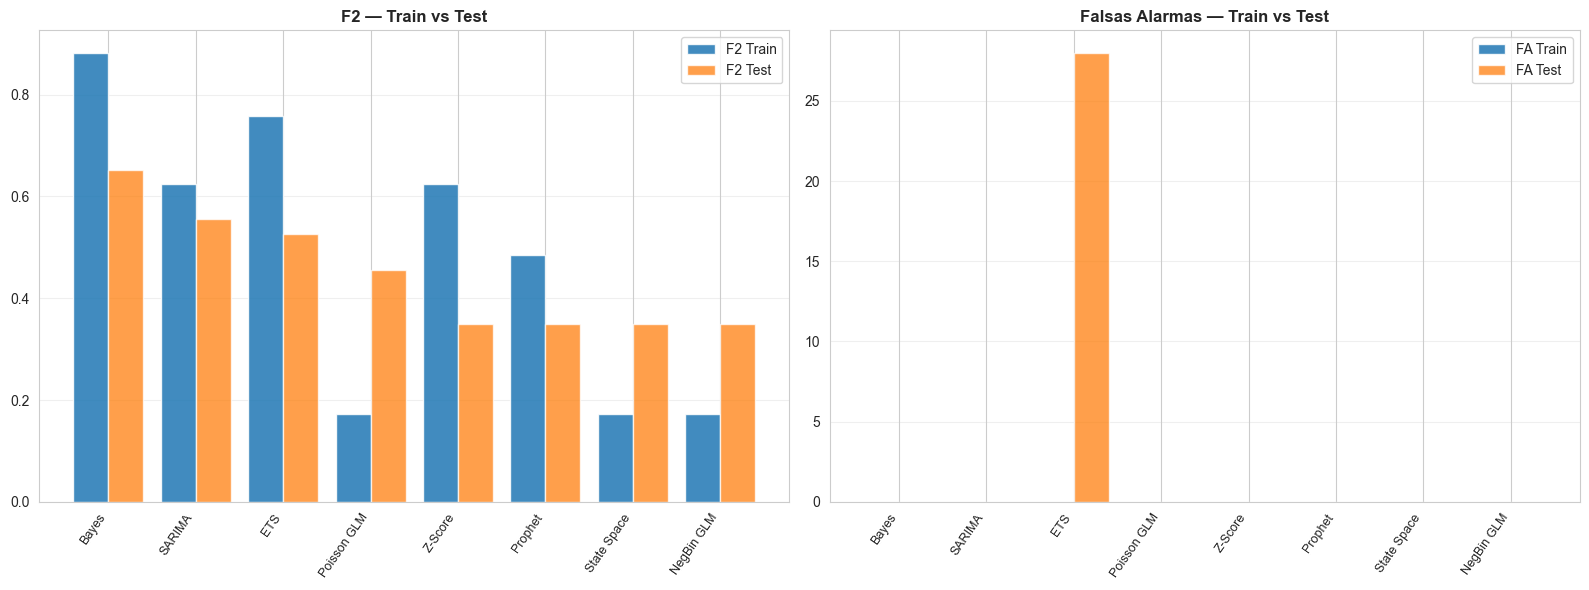

In [46]:
import numpy as np
import matplotlib.pyplot as plt

modelos = overfit_df["Modelo"].values
x = np.arange(len(modelos))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# F2
axes[0].bar(x - 0.2, overfit_df["F2 Train"], 0.4, label="F2 Train", alpha=0.85)
axes[0].bar(x + 0.2, overfit_df["F2 Test"],  0.4, label="F2 Test",  alpha=0.75)
axes[0].set_xticks(x)
axes[0].set_xticklabels(modelos, rotation=55, ha="right", fontsize=9)
axes[0].set_title("F2 — Train vs Test", fontweight="bold")
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis="y")

# Falsas alarmas
axes[1].bar(x - 0.2, overfit_df["FA Train"], 0.4, label="FA Train", alpha=0.85)
axes[1].bar(x + 0.2, overfit_df["FA Test"],  0.4, label="FA Test",  alpha=0.75)
axes[1].set_xticks(x)
axes[1].set_xticklabels(modelos, rotation=55, ha="right", fontsize=9)
axes[1].set_title("Falsas Alarmas — Train vs Test", fontweight="bold")
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

## 12. Desempeño Mínimo Aceptable

### ¿Cuál debería ser el desempeño mínimo a obtener?

Para establecer el umbral mínimo de desempeño, consideramos tres referencias:

| Referencia | F2-Score | Recall | Justificación |
|------------|----------|--------|---------------|
| **Aleatorio proporcional** | ~0.10 | ~0.10 | Predecir brote con probabilidad = tasa base |
| **Baseline mínimo útil** | ≥ 0.30 | ≥ 0.50 | Detectar al menos la mitad de los brotes |

> **Desempeño mínimo propuesto:** F2 ≥ 0.30 y Recall ≥ 0.50
>
> Un modelo que detecte al menos la mitad de los brotes con un número razonable de falsas alarmas ya aporta valor operativo en vigilancia epidemiológica.

In [47]:
import numpy as np
import pandas as pd

MIN_F2 = 0.30
MIN_RECALL = 0.50

if "df_comp" not in globals() or df_comp is None or len(df_comp) == 0:
    print("No existe df_comp. Ejecuta primero la sección de comparación (tabla final de modelos).")
else:
    df_check = df_comp.copy()

    if "F2" in df_check.columns:
        df_check["Cumple_F2"] = pd.to_numeric(df_check["F2"], errors="coerce") >= MIN_F2
    else:
        df_check["Cumple_F2"] = np.nan

    if "Recall" in df_check.columns:
        df_check["Cumple_Recall"] = pd.to_numeric(df_check["Recall"], errors="coerce") >= MIN_RECALL
    else:
        df_check["Cumple_Recall"] = np.nan

    if "Delay_promedio" in df_check.columns:
        df_check["Delay_promedio"] = pd.to_numeric(df_check["Delay_promedio"], errors="coerce")

    cols = [
        "Modelo", "Precision", "Recall", "F2",
        "Falsas_alarmas", "Delay_promedio",
        "Cumple_F2", "Cumple_Recall"
    ]
    cols = [c for c in cols if c in df_check.columns]

    display(df_check[cols].sort_values(["Cumple_F2", "Cumple_Recall"], ascending=False))


,Modelo,Precision,Recall,F2,Falsas_alarmas,Cumple_F2,Cumple_Recall
0,Z-Score Global (z > 0.0),1.000,0.882,0.904,0,True,True
1,Z-Score Rolling 12m (z > 0.0),1.000,0.846,0.873,0,True,True
2,Bayesiano Jerárquico (α=0.05),1.000,0.706,0.750,0,True,True
3,Isolation Forest,0.619,0.765,0.730,8,True,True
4,Holt-Winters resid > 0.50σ,0.317,0.765,0.596,28,True,True
5,SARIMA resid > 0.50σ,1.000,0.529,0.584,0,True,True
6,Prophet,1.000,0.353,0.405,0,True,False
7,Poisson GLM (residuo > 2.0),1.000,0.294,0.342,0,True,False
8,Espacio de estados,1.000,0.235,0.278,0,False,False
9,NegBin GLM (residuo > 2.0),1.000,0.235,0.278,0,False,False


# 10. Conclusiones y Trabajo Futuro (Enfoque: Predicción)

### 1. Evaluación del Baseline de Pronóstico
Aunque se exploraron técnicas de detección de anomalías, el único modelo con capacidad de **captura alta variabilidad y es flexible para eventos raros** evaluado fue **Bayesiano jerárquico**.
* Ya que resentó el mejor equilibrio entre Recall y F2-Score, además de mantener un nivel bajo de falsas alarmas, lo cual es deseable en contextos de salud pública donde la detección temprana es prioritaria. Este modelo es especialmente adecuado debido a la naturaleza discreta y esporádica de los casos de sarampión, así como su capacidad para manejar incertidumbre y baja frecuencia de eventos.
* Los modelos **Z-Score** e **Isolation Forest** se descartan como predictores, ya que operan sobre datos concurrentes y no ofrecen una estimación a futuro.

### 2. Problema con la cantidad de meses en Ceros
Aproximadamente 90% del los datos reportan 0 casos.

* Esto plantea un desafío para la regresión: un modelo que prediga siempre "0" tendrá un error matemático muy bajo (buen RMSE), pero será inútil epidemiológicamente porque fallará en predecir el único evento que importa (el brote).

### 3. Estrategia de Modelado Futuro
Para cumplir con el objetivo de **predecir la cantidad de casos**, la siguiente etapa cambiará el enfoque hacia **Regresión Supervisada de Series de Tiempo**:

* **Nuevas Métricas:** Se dejará de usar F2/Recall. Se evaluará mediante **RMSE** (Error Cuadrático Medio) y **MAE** (Error Absoluto Medio), poniendo especial atención al error en los meses con casos > 0.
* **Algoritmos Candidatos:**
    * **XGBoost/LightGBM Regressor:** Utilizando los **Lags (12-14 meses)** identificados en el EDA como predictores clave. Se configurarán con funciones de pérdida objetivas para conteos (ej. **Regresión de Poisson** o **Tweedie**) para manejar mejor la naturaleza de eventos raros y valores discretos.